In [25]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MonthLocator
import matplotlib.ticker as mtick
import os
import json
import sys
import datetime
from datetime import date
from matplotlib.dates import MO, WeekdayLocator, MonthLocator, YearLocator
from datetime import datetime, UTC, date
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter, MO

plots_filepath = 'plots/pre-june-25'

# Append utils to path for logo import
sys.path.append("utils")
from logo import add_logo

def format_date_with_suffix(date_obj):
    # 1) turn str or datetime/date into a pd.Timestamp
    ts = pd.to_datetime(date_obj)

    # 2) get the day and compute the ordinal suffix
    day = ts.day
    if 10 <= day % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')

    # 3) build the final string
    #    Month name: ts.strftime('%B')
    #    Day + suffix: f'{day}{suffix}'
    #    Year: ts.year
    return f"{ts.strftime('%B')} {day}{suffix}, {ts.year}"


today = datetime.today()
date = format_date_with_suffix(today)

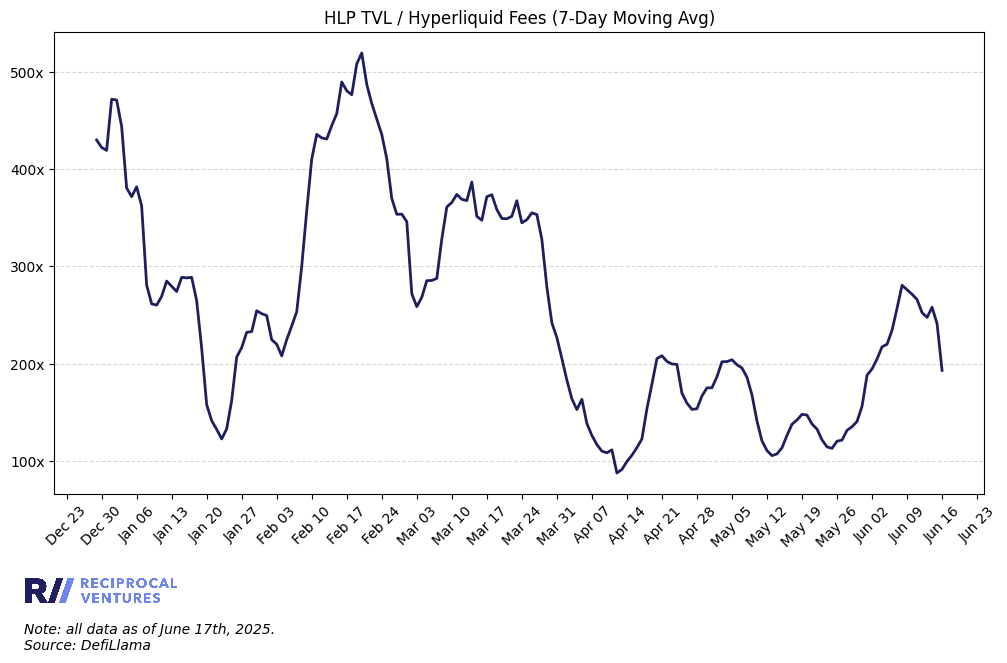

          date           tvl     fees  tvl-to-fees  tvl-to-fees-7d
164 2025-06-06  4.189670e+08  1869461   224.111112      234.398495
165 2025-06-07  4.198417e+08   918833   456.929298      257.013001
166 2025-06-08  4.278171e+08   820745   521.254574      280.617368
167 2025-06-10  4.145958e+08  2769078   149.723411      271.449559
168 2025-06-11  4.054813e+08  2778271   145.947347      265.975760
169 2025-06-12  4.098099e+08  3036346   134.968112      252.487839
170 2025-06-13  4.070069e+08  4035028   100.868426      247.686040
171 2025-06-14  4.017230e+08  1353343   296.837534      258.075529
172 2025-06-15  4.028596e+08  1190441   338.412052      241.144494
173 2025-06-16  4.041456e+08  2181067   185.297205      193.150584


In [26]:
# Load Hyperliquid fees data
with open("raw-data/defillama-raw-data/defillama_hyperliquid-fees.json", "r") as f:
    fee_data = json.load(f)

fee_df = pd.DataFrame(fee_data["totalDataChart"], columns=["timestamp", "fees"])
fee_df["date"] = pd.to_datetime(fee_df["timestamp"], unit="s")
fee_df = fee_df[["date", "fees"]]

# Load HLP TVL data
with open("raw-data/defillama-raw-data/defillama_HLP.json", "r") as f:
    hlp_data = json.load(f)

hlp_raw = hlp_data["chainTvls"]["Hyperliquid L1"]["tvl"]
hlp_df = pd.DataFrame(hlp_raw)
hlp_df["date"] = pd.to_datetime(hlp_df["date"], unit="s")
hlp_df = hlp_df.rename(columns={"totalLiquidityUSD": "tvl"})
hlp_df = hlp_df[["date", "tvl"]]

# Merge datasets
df = pd.merge(hlp_df, fee_df, on="date", how="inner")
df["tvl-to-fees"] = df["tvl"] / df["fees"]

# Calculate trailing 7-day average
df["tvl-to-fees-7d"] = df["tvl-to-fees"].rolling(window=7).mean()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df["date"], df["tvl-to-fees-7d"], color="#1f1f60", linewidth=2, label="7D Avg")

# X-axis formatting for weekly ticks
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# Y-axis formatting
ax.set_title("HLP TVL / Hyperliquid Fees (7-Day Moving Avg)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}x'))

# X-axis formatting: show ticks weekly, on Mondays
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)
add_logo(ax, position=(0.05, -0.21))
plt.figtext(0.1, -0.15, f"Note: all data as of {date}.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')

# Save plot
if not os.path.exists("plots"):
    os.makedirs("plots")
plt.savefig(f"{plots_filepath}/tvl-to-fees_ratio_7d_avg.png", dpi=300, bbox_inches='tight')
plt.show()

# Print sample of the dataset with 7D average
print(df[["date", "tvl", "fees", "tvl-to-fees", "tvl-to-fees-7d"]].tail(10))

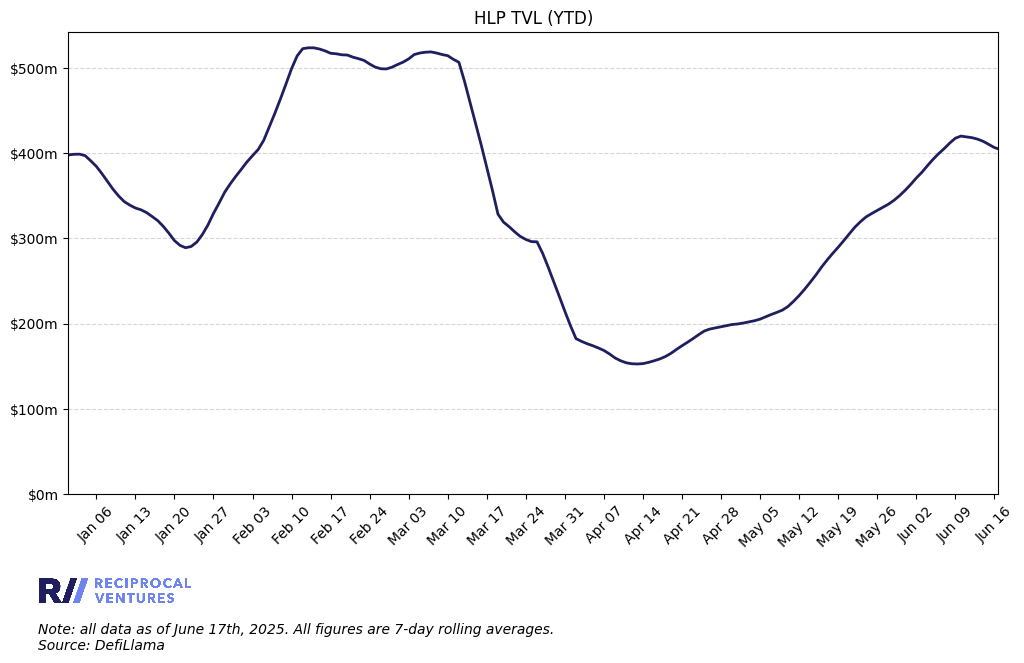

                   date           tvl        tvl-7d
189 2025-06-08 00:00:00  4.278171e+08  4.118152e+08
190 2025-06-09 00:00:00  4.302763e+08  4.175096e+08
191 2025-06-10 00:00:00  4.145958e+08  4.199902e+08
192 2025-06-11 00:00:00  4.054813e+08  4.189951e+08
193 2025-06-12 00:00:00  4.098099e+08  4.181127e+08
194 2025-06-13 00:00:00  4.070069e+08  4.164041e+08
195 2025-06-14 00:00:00  4.017230e+08  4.138158e+08
196 2025-06-15 00:00:00  4.028596e+08  4.102504e+08
197 2025-06-16 00:00:00  4.041456e+08  4.065174e+08
198 2025-06-16 17:38:11  4.045579e+08  4.050835e+08


In [27]:
# Load HLP TVL data
with open("raw-data/defillama-raw-data/defillama_HLP.json", "r") as f:
    hlp_data = json.load(f)

hlp_raw = hlp_data["chainTvls"]["Hyperliquid L1"]["tvl"]
hlp_df = pd.DataFrame(hlp_raw)
hlp_df["date"] = pd.to_datetime(hlp_df["date"], unit="s")
hlp_df = hlp_df.rename(columns={"totalLiquidityUSD": "tvl"})
hlp_df = hlp_df[["date", "tvl"]]

# Calculate trailing 7-day average
hlp_df['tvl-7d'] = hlp_df['tvl'].rolling(window=7).mean()

# Make data YTD
hlp_df = hlp_df[hlp_df['date'] >= '2025-01-01']

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(hlp_df["date"], hlp_df["tvl-7d"], color="#1f1f60", linewidth=2, label="7D Avg")

# X-axis formatting for weekly ticks
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.margins(x=0)
ax.set_ylim(bottom=0)

# Y-axis formatting
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:,.0f}m'))

# X-axis formatting: show ticks weekly, on Mondays
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

ax.set_title("HLP TVL (YTD)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
add_logo(ax, position=(0.05, -0.21))
plt.figtext(0.1, -0.15, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')

# Save plot
if not os.path.exists("plots"):
    os.makedirs("plots")
plt.savefig(f"{plots_filepath}/hlp-tvl_7d_avg.png", dpi=300, bbox_inches='tight')
plt.show()

# Print sample of the dataset with 7D average
print(hlp_df[["date", "tvl", "tvl-7d"]].tail(10))

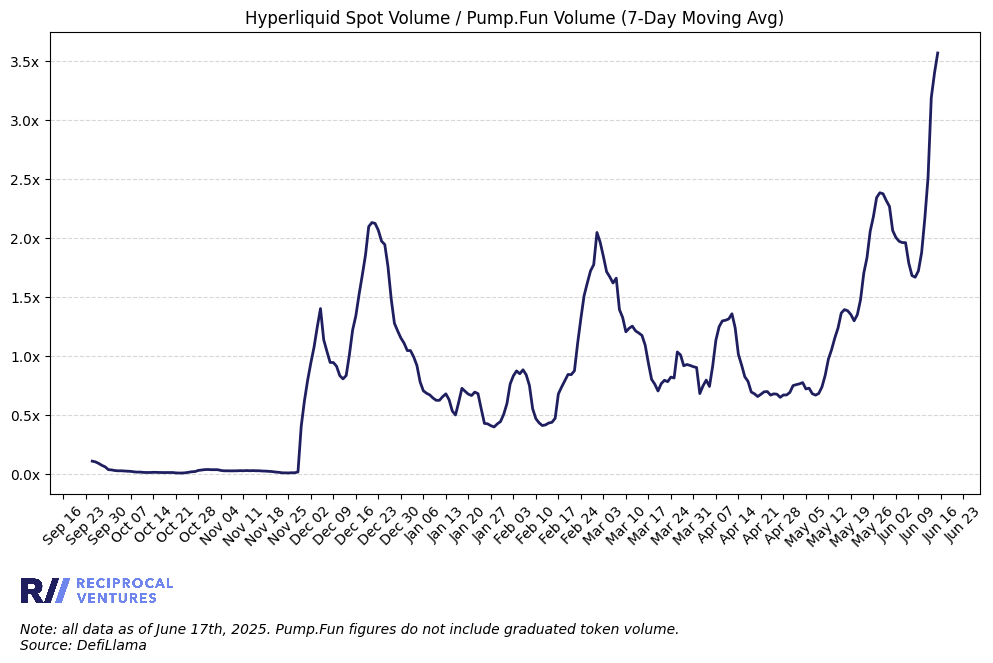

          date  hyperliquid-spot-volume  hyperliquid-spot-volume  \
260 2025-06-06                263764756                263764756   
261 2025-06-07                137044111                137044111   
262 2025-06-08                151362843                151362843   
263 2025-06-09                359240055                359240055   
264 2025-06-10                493501254                493501254   
265 2025-06-11                491823654                491823654   
266 2025-06-12                499156091                499156091   
267 2025-06-13                642044619                642044619   
268 2025-06-14                223313776                223313776   
269 2025-06-15                208088792                208088792   

     hyperliquid-memecoin-market-share  hyperliquid-memecoin-market-share-7d  
260                           1.601928                              1.788040  
261                           1.031094                              1.681789  
262           

In [28]:
# Load Hyperliquid spot volume data
with open("raw-data/defillama-raw-data/defillama_hyperliquid-spot-volumes.json", "r") as f:
    hyperliquid_spot_volume_data = json.load(f)

hyperliquid_spot_volume_df = pd.DataFrame(hyperliquid_spot_volume_data["totalDataChart"], columns=["timestamp", "hyperliquid-spot-volume"])
hyperliquid_spot_volume_df["date"] = pd.to_datetime(hyperliquid_spot_volume_df["timestamp"], unit="s")
hyperliquid_spot_volume_df = hyperliquid_spot_volume_df[["date", "hyperliquid-spot-volume"]]

# Load Pump.Fun volume data
with open("raw-data/defillama-raw-data/defillama_pumpfun-spot-volumes.json", "r") as f:
    pumpfun_spot_volume_data = json.load(f)

pumpfun_spot_volume_df = pd.DataFrame(pumpfun_spot_volume_data["totalDataChart"], columns=["timestamp", "pumpfun-spot-volume"])
pumpfun_spot_volume_df["date"] = pd.to_datetime(pumpfun_spot_volume_df["timestamp"], unit="s")
pumpfun_spot_volume_df = pumpfun_spot_volume_df[["date", "pumpfun-spot-volume"]]

# Merge datasets
df = pd.merge(hyperliquid_spot_volume_df, pumpfun_spot_volume_df, on="date", how="inner")
df["hyperliquid-memecoin-market-share"] = df["hyperliquid-spot-volume"] / df["pumpfun-spot-volume"]

# Calculate trailing 7-day average
df["hyperliquid-memecoin-market-share-7d"] = df["hyperliquid-memecoin-market-share"].rolling(window=7).mean()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df["date"], df["hyperliquid-memecoin-market-share-7d"], color="#1f1f60", linewidth=2, label="7D Avg")

# X-axis formatting: show ticks weekly, on Mondays
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

# Y-axis formatting
ax.set_title("Hyperliquid Spot Volume / Pump.Fun Volume (7-Day Moving Avg)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}x'))

plt.grid(axis='y', linestyle='--', alpha=0.5)
add_logo(ax, position=(0.05, -0.21))
plt.figtext(0.1, -0.15, f"Note: all data as of {date}. Pump.Fun figures do not include graduated token volume.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')

# Save plot
if not os.path.exists("plots"):
    os.makedirs("plots")
plt.savefig(f"{plots_filepath}/hyperliquid-to-pumpfun-volume-ratio_7d_avg.png", dpi=300, bbox_inches='tight')
plt.show()

# Print sample of the dataset with 7D average
print(df[["date", "hyperliquid-spot-volume", "hyperliquid-spot-volume", "hyperliquid-memecoin-market-share", "hyperliquid-memecoin-market-share-7d"]].tail(10))

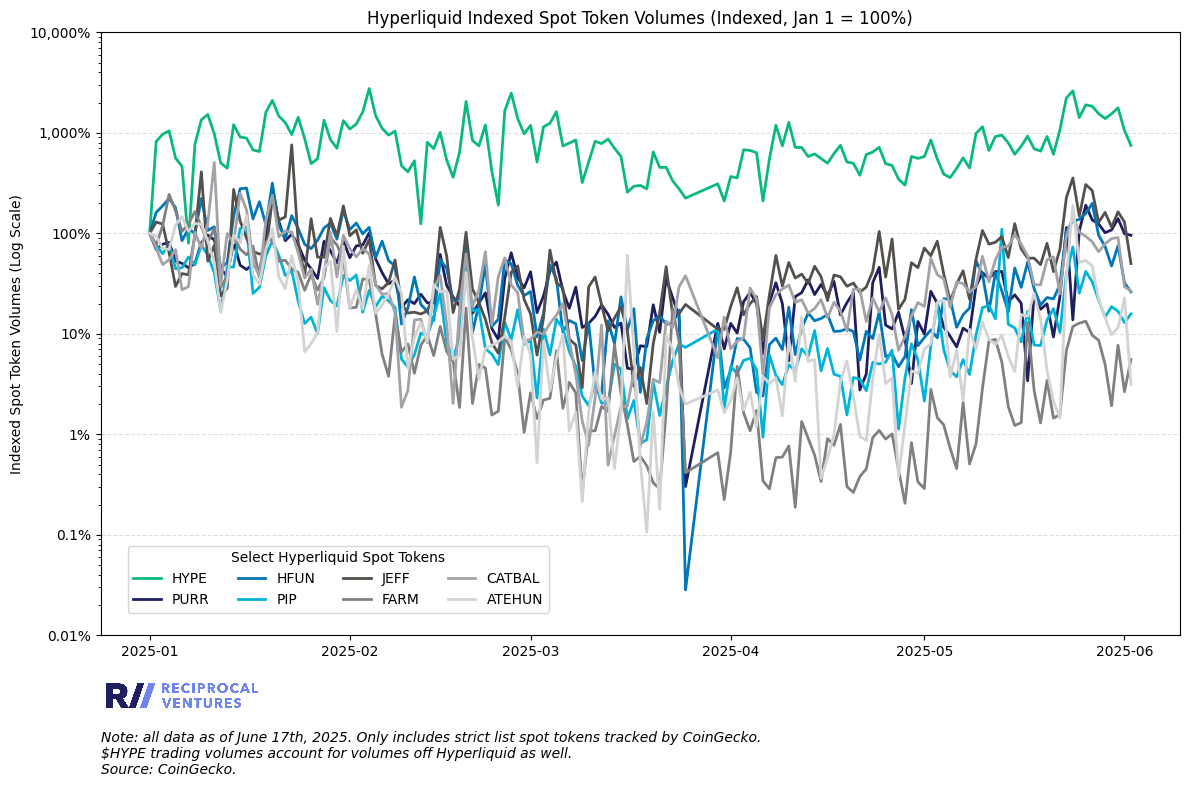

          date         HYPE        PURR        HFUN        PIP        JEFF  \
139 2025-05-24  2611.254056   13.771637  132.514160  73.150593  355.007260   
140 2025-05-25  1415.947008  105.961711  137.525570  25.389732  148.228978   
141 2025-05-26  1897.824460  190.447776  157.375344  41.810773  305.880294   
142 2025-05-27  1838.278973  136.096821  198.822511  32.983178  266.846372   
143 2025-05-28  1552.411245  123.648530   95.539075  21.649451  128.712558   
144 2025-05-29  1386.530116  101.469773   73.812582  14.673270  161.432416   
145 2025-05-30  1545.336776  108.052428   47.249667  18.641349  115.454538   
146 2025-05-31  1771.563692  140.057719   75.182832  16.749192  163.408209   
147 2025-06-01  1054.471756   99.284700   32.127623  12.942251  129.515219   
148 2025-06-02   749.286963   95.659546   26.121201  15.783170   50.022165   

          FARM      CATBAL      ATEHUN  
139  11.811209  145.346441  188.979225  
140  12.772277  102.771933   51.210581  
141  13.362678   9

In [29]:
# Load Hyperliquid spot stric list volume data

# Load color palette
color_palette = {
    'Hyperliquid':'#09b882', 'Black':'#000000',
    'Bold Blue':'#1f1f60', 'Sky Blue':'#6f85ee',
    'blue 1':'#03045e', 'blue 2':'#0077b6',
    'blue 3':'#00b4d8', 'blue 4':'#90e0ef',
    'blue 5':'#caf0f8', 'blue 6':'#d9f4fa', 'blue 7': '#f1fcfe',
    'Mid Grey':'#54504c','Other Grey':'#a4a2a8', 'Pure Grey': '#808080','Lighter Grey': '#A9A9A9','Lightest Grey': '#D3D3D3',
}

asset_colors = {
    'HYPE': color_palette['Hyperliquid'],
    'PURR': color_palette['Bold Blue'],
    'HFUN': color_palette['blue 2'],
    'PIP': color_palette['blue 3'],
    'JEFF': color_palette['Mid Grey'],
    'FARM': color_palette['Pure Grey'],
    'CATBAL': color_palette['Other Grey'],
    'ATEHUN': color_palette['Lightest Grey'],
}

# Create asset map
assets = {
    'hyperliquid': 'HYPE',
    "purr-2": "PURR",
    "hypurr-fun": "HFUN",
    "pip-3": "PIP",
    "jeff-3": "JEFF",
    "farm-2": "FARM",
    "catbal": "CATBAL",
    'atehun': 'ATEHUN',
}

df_master = None

for raw_id, asset in assets.items():
    # Load data spot asset data
    path = f"raw-data/coingecko-raw-data/coingecko_{raw_id}_spot_strict_list_data.json"
    with open(path) as f:
        data = json.load(f)

    coin_df = (
        pd.DataFrame(data["total_volumes"], columns=["timestamp", f"{asset}-spot-volume"])
          .assign(date=lambda d: pd.to_datetime(d["timestamp"], unit="ms"))
          .loc[:, ["date", f"{asset}-spot-volume"]]
    )

    # Transform data to 7d avg index
    first_volume = coin_df[f"{asset}-spot-volume"].iloc[0]
    coin_df[f"{asset}-indexed-spot-volume"] = coin_df[f"{asset}-spot-volume"] / first_volume * 100
    coin_df[f"{asset}-indexed-spot-volume-7d"] = coin_df[f"{asset}-indexed-spot-volume"].rolling(7).mean()
    coin_df[f'{asset}-spot-volume-7d'] = coin_df[f'{asset}-spot-volume'].rolling(7).mean()

    # Kill values not getting plotted
    coin_df[f'{asset}'] = coin_df[f"{asset}-indexed-spot-volume"]
    coin_df = coin_df[["date", f"{asset}"]]
    
    # Merge dataframes
    df_master = coin_df if df_master is None else df_master.merge(coin_df, on="date", how="inner")
    df_master = df_master.sort_values("date").reset_index(drop=True)

# Create the line chart
fig, ax = plt.subplots(figsize=(12, 8))

# Plotting the line chart with custom colors
for raw_id, asset in assets.items():
    ax.plot(
        df_master['date'], 
        df_master[asset], 
        label=asset, 
        color=asset_colors[asset],
        linewidth=2
    )

# Setting labels and title
ax.set_title('Hyperliquid Indexed Spot Token Volumes (Indexed, Jan 1 = 100%)')
ax.set_ylabel('Indexed Spot Token Volumes (Log Scale)')

# Set y-axis to logarithmic scale
ax.set_yscale('log')

# Apply a percentage formatter to the y-axis
def format_y(x, _):
    """Integers for values ≥ 1, variable decimals for values < 1."""
    if x >= 1:
        return f"{x:,.0f}%" # e.g. 2 000
    # format to 10 dp then strip trailing zeros/decimal point
    return f"{x:.10f}".rstrip("0").rstrip(".")+"%"

ax.yaxis.set_major_formatter(mtick.FuncFormatter(format_y))

# Set y-axis limits with lower bound as 10 (10^1)
ax.set_ylim(0.01, 10000)

# Add grid lines for better readability
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Add logo
add_logo(ax, position=(0.075, -0.1))

# Add sources and note
text_box = ax.text(0, -0.23, f"Note: all data as of {date}. Only includes strict list spot tokens tracked by CoinGecko.\n$HYPE trading volumes account for volumes off Hyperliquid as well.\nSource: CoinGecko.",
                   ha='left', transform=ax.transAxes, fontsize=10,
                   bbox=dict(facecolor='white', alpha=0), fontstyle='italic')

# Center the legend below the chart
plt.legend(title='Select Hyperliquid Spot Tokens', bbox_to_anchor=(0.22, 0.16), loc='upper center', ncol=4)

# Ensure the layout adapts to fit all elements (legend, text, etc.)
plt.tight_layout()

# Save plot
if not os.path.exists("plots"):
    os.makedirs("plots")
plt.savefig(f"{plots_filepath}/hyperliquid-indexed-spot-token-volumes.png", dpi=300, bbox_inches='tight')

# Show
plt.show()
print(df_master.tail(10))

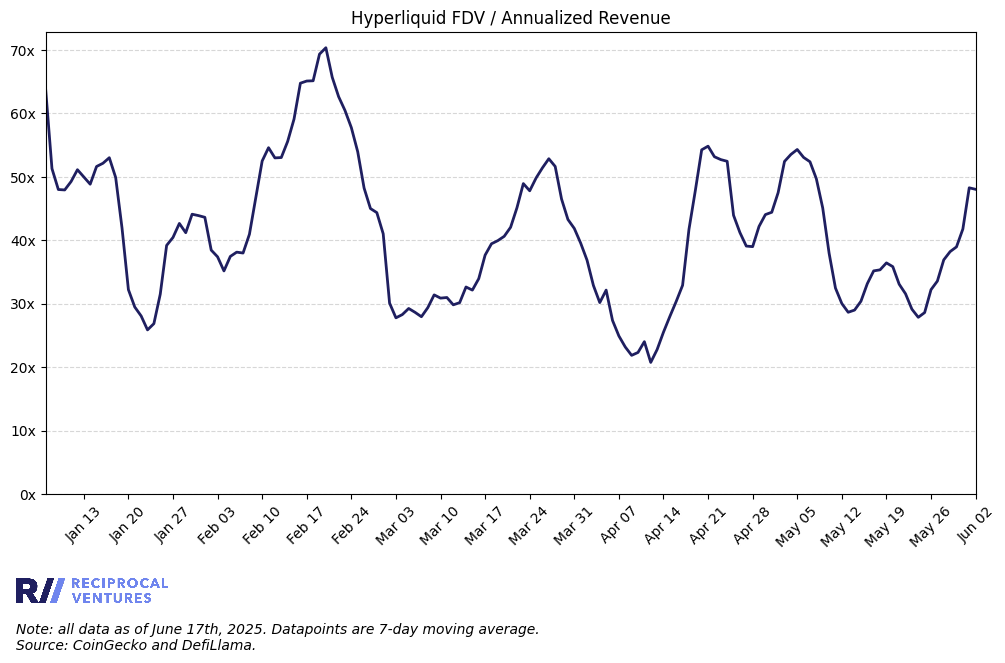

          date     fees  annualized-fees      price           fdv  \
142 2025-05-24  1772587        646994255  32.717636  3.271764e+10   
143 2025-05-25  2509394        915928810  35.152205  3.515220e+10   
144 2025-05-26  2008565        733126225  38.806031  3.880603e+10   
145 2025-05-27  3093316       1129060340  37.236931  3.723693e+10   
146 2025-05-28  2528143        922772195  36.014968  3.601497e+10   
147 2025-05-29  3133950       1143891750  34.285752  3.428575e+10   
148 2025-05-30  3017044       1101221060  31.665854  3.166585e+10   
149 2025-05-31  1266132        462138180  32.457689  3.245769e+10   
150 2025-06-01  1073894        391971310  32.875513  3.287551e+10   
151 2025-06-02  1825242        666213330  34.153797  3.415380e+10   

     hype-fdv-rev-multiple  hype-fdv-rev-multiple-7d  
142              50.568666                 27.844625  
143              38.378752                 28.589943  
144              52.932264                 32.200677  
145              32.

In [30]:
# total supply for FDV
total_hype_tokens = 1000000000

# Load Hyperliquid fees data
with open("raw-data/defillama-raw-data/defillama_hyperliquid-fees.json", "r") as f:
    fee_data = json.load(f)

fee_df = pd.DataFrame(fee_data["totalDataChart"], columns=["timestamp_s", "fees"])
fee_df["date"] = pd.to_datetime(fee_df["timestamp_s"], unit="s").dt.normalize()
fee_df = fee_df[["date", "fees"]]
fee_df['annualized-fees'] = fee_df['fees'] * 365

# Load Hyperliquid close price data
with open("raw-data/coingecko-raw-data/coingecko_hyperliquid_spot_strict_list_data.json", "r") as f:
    price_data = json.load(f)

price_df = pd.DataFrame(price_data["prices"], columns=["timestamp_ms", "price"])
price_df["date"] = pd.to_datetime(price_df["timestamp_ms"], unit="ms").dt.normalize()  # use price_df, unit=ms
price_df = price_df[["date", "price"]]
price_df["fdv"] = price_df["price"] * total_hype_tokens

# Merge Hyperliquid datasets
df = pd.merge(fee_df, price_df, on="date", how="inner")

df["hype-fdv-rev-multiple"] = df["fdv"] / df["annualized-fees"]

# Calculate trailing 7-day average
df["hype-fdv-rev-multiple-7d"] = df["hype-fdv-rev-multiple"].rolling(window=7).mean()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df["date"], df["hype-fdv-rev-multiple-7d"], color="#1f1f60", linewidth=2, label="7D Avg")

# X-axis formatting: show ticks weekly, on Mondays
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
ax.margins(x=0)
ax.set_ylim(bottom=0)

# Y-axis formatting
ax.set_title("Hyperliquid FDV / Annualized Revenue")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}x'))

plt.grid(axis='y', linestyle='--', alpha=0.5)
add_logo(ax, position=(0.05, -0.21))
plt.figtext(0.1, -0.15, f"Note: all data as of {date}. Datapoints are 7-day moving average. \nSource: CoinGecko and DefiLlama.", ha='left', fontsize=10, style='italic')

# Save plot
if not os.path.exists("plots"):
    os.makedirs("plots")
plt.savefig(f"{plots_filepath}/hyperliquid_fdv_to_annualized-revenue_7d_avg.png", dpi=300, bbox_inches='tight')
plt.show()

print(df.tail(10))

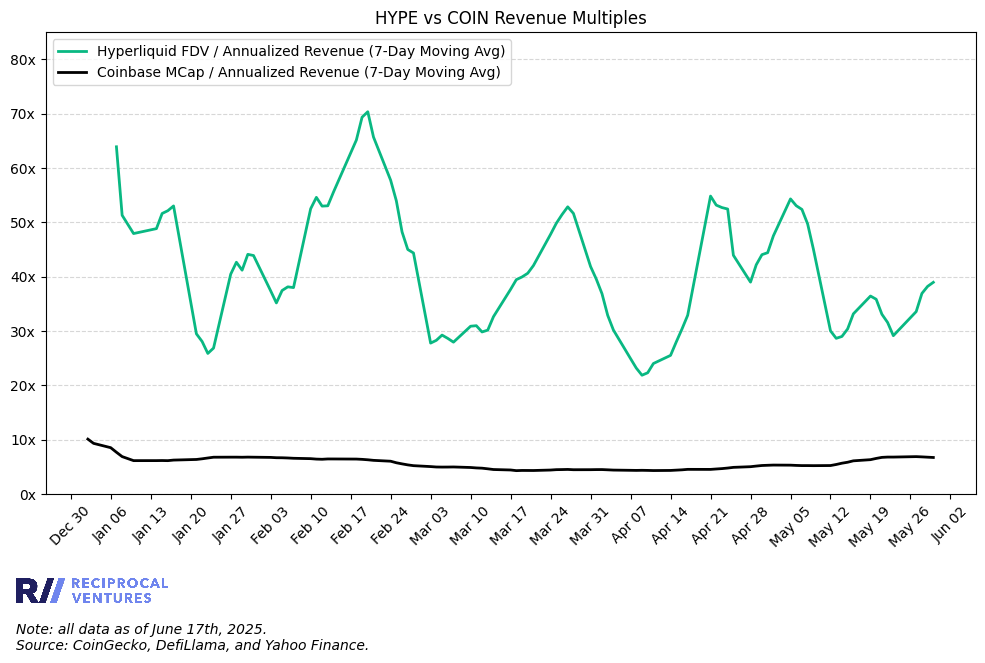

          date     fees  annualized-fees      price           fdv  \
91  2025-05-16  1765154        644281210  26.089948  2.608995e+10   
92  2025-05-19  2667980        973812700  26.932859  2.693286e+10   
93  2025-05-20  3097173       1130468145  26.566693  2.656669e+10   
94  2025-05-21  4645476       1695598740  26.496507  2.649651e+10   
95  2025-05-22  3697213       1349482745  28.170044  2.817004e+10   
96  2025-05-23  3872157       1413337305  33.246088  3.324609e+10   
97  2025-05-27  3093316       1129060340  37.236931  3.723693e+10   
98  2025-05-28  2528143        922772195  36.014968  3.601497e+10   
99  2025-05-29  3133950       1143891750  34.285752  3.428575e+10   
100 2025-05-30  3017044       1101221060  31.665854  3.166585e+10   

     hype-fdv-rev-multiple  hype-fdv-rev-multiple-7d  coin_market_cap  \
91               40.494660                 33.144801     5.633151e+10   
92               27.657125                 36.421032     5.580933e+10   
93               23.5

In [31]:
# total supply for FDV
total_hype_tokens = 1000000000

# Load Hyperliquid fees data
with open("raw-data/defillama-raw-data/defillama_hyperliquid-fees.json", "r") as f:
    fee_data = json.load(f)

fee_df = pd.DataFrame(fee_data["totalDataChart"], columns=["timestamp_s", "fees"])
fee_df["date"] = pd.to_datetime(fee_df["timestamp_s"], unit="s")
fee_df = fee_df[["date", "fees"]]
fee_df['annualized-fees'] = fee_df['fees'] * 365

# Load Hyperliquid close price data
with open("raw-data/coingecko-raw-data/coingecko_hyperliquid_spot_strict_list_data.json", "r") as f:
    price_data = json.load(f)

price_df = pd.DataFrame(price_data["prices"], columns=["timestamp_ms", "price"])
price_df["date"] = pd.to_datetime(price_df["timestamp_ms"], unit="ms")  # use price_df, unit=ms
price_df = price_df[["date", "price"]]
price_df["fdv"] = price_df["price"] * total_hype_tokens

# Merge Hyperliquid datasets
df = pd.merge(fee_df, price_df, on="date", how="inner")
df["hype-fdv-rev-multiple"] = df["fdv"] / df["annualized-fees"]

# Calculate trailing 7-day average
df["hype-fdv-rev-multiple-7d"] = df["hype-fdv-rev-multiple"].rolling(window=7).mean()

# Load Coinbase close price data
with open("raw-data/yahoofinance-raw-data/COIN_mcap_to_annualized_rev.json", "r") as f:
    mcap_data = json.load(f)
mcap_df = pd.DataFrame.from_dict(mcap_data, orient="index")
mcap_df.index.name = "date"
mcap_df.reset_index(inplace=True)
mcap_df["date"] = pd.to_datetime(mcap_df["date"])

df = pd.merge(df, mcap_df, on="date", how="inner")

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    df["date"], df["hype-fdv-rev-multiple-7d"], color='#09b882',
    linewidth=2, label="Hyperliquid FDV / Annualized Revenue (7-Day Moving Avg)"
)
ax.plot(
    df["date"], df["coin_7d_avg"], color='black',
    linewidth=2, label="Coinbase MCap / Annualized Revenue (7-Day Moving Avg)"
)


# X-axis formatting: show ticks weekly, on Mondays
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

# Y-axis formatting
ax.set_title("HYPE vs COIN Revenue Multiples")
ax.set_ylim(0, 85)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}x'))

plt.grid(axis='y', linestyle='--', alpha=0.5)
add_logo(ax, position=(0.05, -0.21))
ax.legend(loc="upper left")
plt.figtext(0.1, -0.15, f"Note: all data as of {date}.\nSource: CoinGecko, DefiLlama, and Yahoo Finance.", ha='left', fontsize=10, style='italic')

# Save plot
if not os.path.exists("plots"):
    os.makedirs("plots")
plt.savefig(f"{plots_filepath}/hyperliquid_vs_coinbase_multiples_7d_avg.png", dpi=300, bbox_inches='tight')
plt.show()

print(df.tail(10))

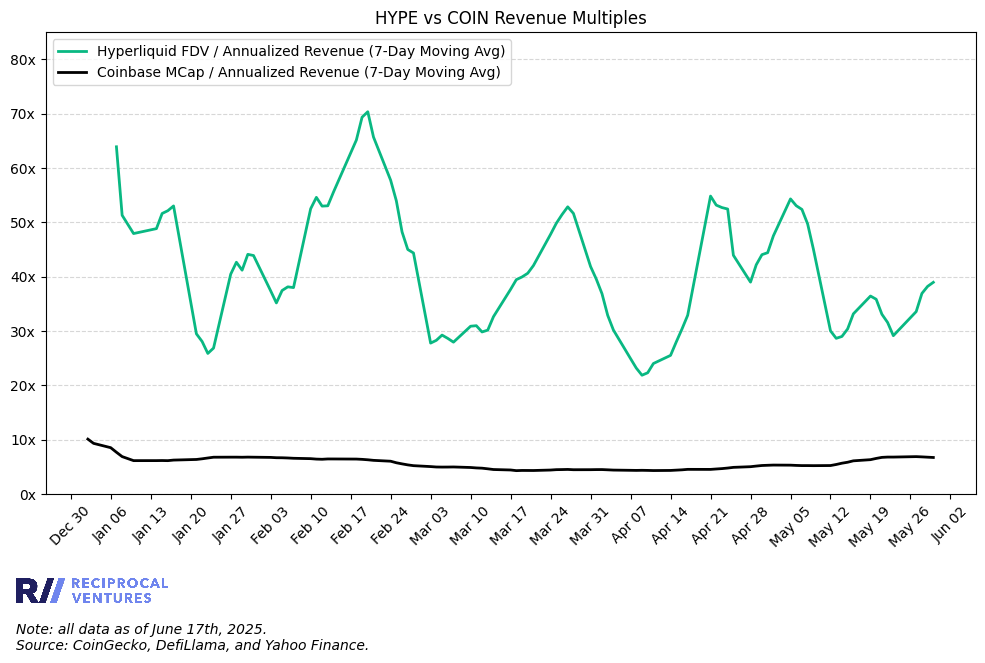

          date     fees  annualized-fees      price           fdv  \
91  2025-05-16  1765154        644281210  26.089948  2.608995e+10   
92  2025-05-19  2667980        973812700  26.932859  2.693286e+10   
93  2025-05-20  3097173       1130468145  26.566693  2.656669e+10   
94  2025-05-21  4645476       1695598740  26.496507  2.649651e+10   
95  2025-05-22  3697213       1349482745  28.170044  2.817004e+10   
96  2025-05-23  3872157       1413337305  33.246088  3.324609e+10   
97  2025-05-27  3093316       1129060340  37.236931  3.723693e+10   
98  2025-05-28  2528143        922772195  36.014968  3.601497e+10   
99  2025-05-29  3133950       1143891750  34.285752  3.428575e+10   
100 2025-05-30  3017044       1101221060  31.665854  3.166585e+10   

     hype-fdv-rev-multiple  hype-fdv-rev-multiple-7d  coin_market_cap  \
91               40.494660                 33.144801     5.633151e+10   
92               27.657125                 36.421032     5.580933e+10   
93               23.5

In [32]:
# total supply for FDV
total_hype_tokens = 1000000000

# Load Hyperliquid fees data
with open("raw-data/defillama-raw-data/defillama_hyperliquid-fees.json", "r") as f:
    fee_data = json.load(f)

fee_df = pd.DataFrame(fee_data["totalDataChart"], columns=["timestamp_s", "fees"])
fee_df["date"] = pd.to_datetime(fee_df["timestamp_s"], unit="s")
fee_df = fee_df[["date", "fees"]]
fee_df['annualized-fees'] = fee_df['fees'] * 365

# Load Hyperliquid close price data
with open("raw-data/coingecko-raw-data/coingecko_hyperliquid_spot_strict_list_data.json", "r") as f:
    price_data = json.load(f)

price_df = pd.DataFrame(price_data["prices"], columns=["timestamp_ms", "price"])
price_df["date"] = pd.to_datetime(price_df["timestamp_ms"], unit="ms")  # use price_df, unit=ms
price_df = price_df[["date", "price"]]
price_df["fdv"] = price_df["price"] * total_hype_tokens

# Merge Hyperliquid datasets
df = pd.merge(fee_df, price_df, on="date", how="inner")
df["hype-fdv-rev-multiple"] = df["fdv"] / df["annualized-fees"]

# Calculate trailing 7-day average
df["hype-fdv-rev-multiple-7d"] = df["hype-fdv-rev-multiple"].rolling(window=7).mean()

# Load Coinbase close price data
with open("raw-data/yahoofinance-raw-data/COIN_mcap_to_annualized_rev.json", "r") as f:
    mcap_data = json.load(f)
mcap_df = pd.DataFrame.from_dict(mcap_data, orient="index")
mcap_df.index.name = "date"
mcap_df.reset_index(inplace=True)
mcap_df["date"] = pd.to_datetime(mcap_df["date"])

df = pd.merge(df, mcap_df, on="date", how="inner")

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    df["date"], df["hype-fdv-rev-multiple-7d"], color='#09b882',
    linewidth=2, label="Hyperliquid FDV / Annualized Revenue (7-Day Moving Avg)"
)
ax.plot(
    df["date"], df["coin_7d_avg"], color='black',
    linewidth=2, label="Coinbase MCap / Annualized Revenue (7-Day Moving Avg)"
)


# X-axis formatting: show ticks weekly, on Mondays
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

# Y-axis formatting
ax.set_title("HYPE vs COIN Revenue Multiples")
ax.set_ylim(0, 85)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}x'))

plt.grid(axis='y', linestyle='--', alpha=0.5)
add_logo(ax, position=(0.05, -0.21))
ax.legend(loc="upper left")
plt.figtext(0.1, -0.15, f"Note: all data as of {date}.\nSource: CoinGecko, DefiLlama, and Yahoo Finance.", ha='left', fontsize=10, style='italic')

# Save plot
if not os.path.exists("plots"):
    os.makedirs("plots")
plt.savefig(f"{plots_filepath}/hyperliquid_vs_coinbase_multiples_7d_avg.png", dpi=300, bbox_inches='tight')
plt.show()

print(df.tail(10))

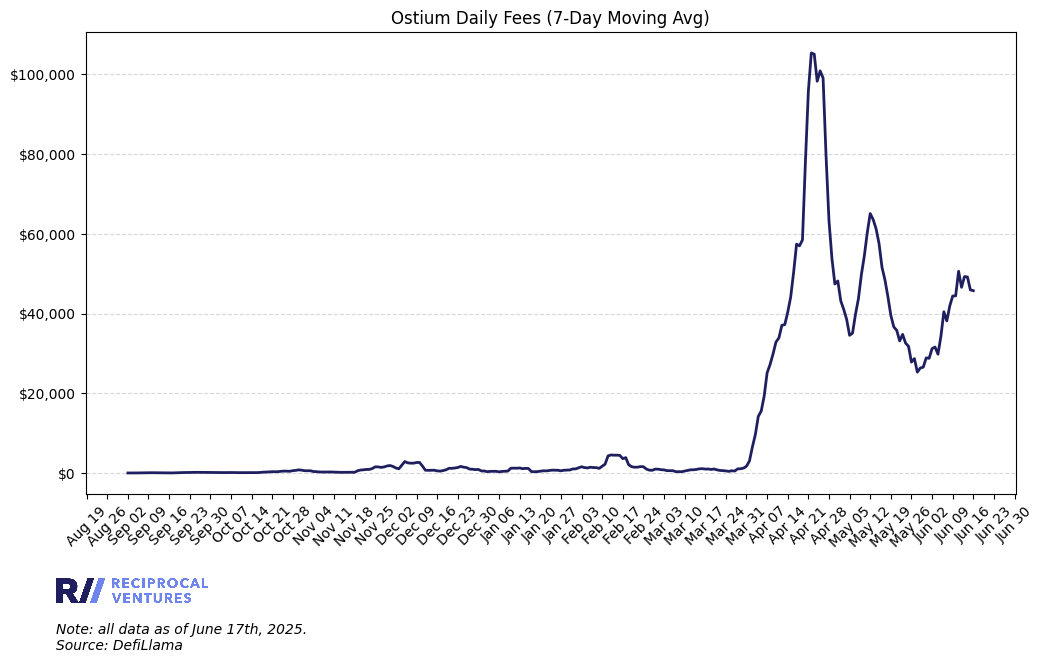

          date  ostium-fees  ostium-fees-7d
284 2025-06-07        10319    38146.714286
285 2025-06-08        43393    41896.000000
286 2025-06-09        54988    44392.714286
287 2025-06-10        34334    44434.857143
288 2025-06-11        58222    50598.000000
289 2025-06-12        44191    46578.571429
290 2025-06-13        99471    49274.000000
291 2025-06-14         9609    49172.571429
292 2025-06-15        20680    45927.857143
293 2025-06-16        53611    45731.142857


In [33]:
# Load Ostium fees data
with open("raw-data/defillama-raw-data/defillama_ostium-fees.json", "r") as f:
    fee_data = json.load(f)

df = pd.DataFrame(fee_data["totalDataChart"], columns=["timestamp", "ostium-fees"])
df["date"] = pd.to_datetime(df["timestamp"], unit="s")
df = df[["date", "ostium-fees"]]

# Calculate trailing 7-day average
df["ostium-fees-7d"] = df["ostium-fees"].rolling(window=7).mean()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df["date"], df["ostium-fees-7d"], color="#1f1f60", linewidth=2, label="7D Avg")

# X-axis formatting for weekly ticks
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# Y-axis formatting
ax.set_title("Ostium Daily Fees (7-Day Moving Avg)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# X-axis formatting: show ticks weekly, on Mondays
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)
add_logo(ax, position=(0.05, -0.21))
plt.figtext(0.1, -0.15, f"Note: all data as of {date}.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')

# Save plot
if not os.path.exists("plots"):
    os.makedirs("plots")
plt.savefig(f"{plots_filepath}/ostium_fees_7d_avg.png", dpi=300, bbox_inches='tight')
plt.show()

# Print sample of the dataset with 7D average
print(df.tail(10))

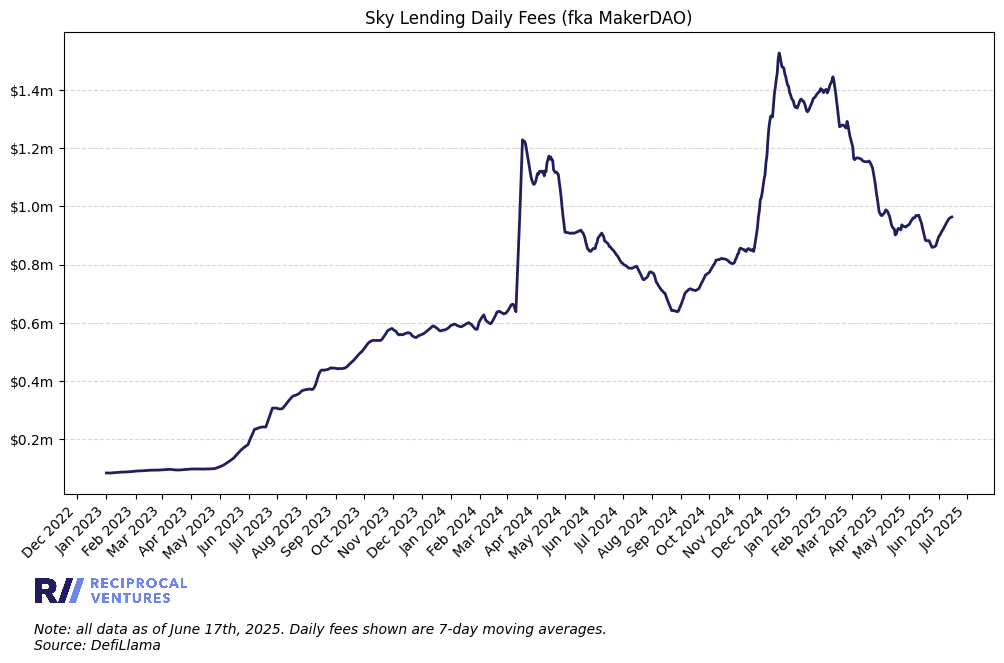

           date  makerdao-fees  makerdao-fees-7d
2030 2025-06-06         935977     922269.857143
2031 2025-06-07         947216     929153.714286
2032 2025-06-08         945101     934741.428571
2033 2025-06-09         970110     941662.000000
2034 2025-06-10         964600     947318.714286
2035 2025-06-11         973069     952573.571429
2036 2025-06-12         967224     957613.857143
2037 2025-06-13         956247     960509.571429
2038 2025-06-14         958573     962132.000000
2039 2025-06-15         955236     963579.857143


In [34]:
# Load MakerDAO fees data
with open("raw-data/defillama-raw-data/defillama_makerdao-fees.json", "r") as f:
    fee_data = json.load(f)

df = pd.DataFrame(fee_data["totalDataChart"], columns=["timestamp", "makerdao-fees"])
df["date"] = pd.to_datetime(df["timestamp"], unit="s")
df = df[["date", "makerdao-fees"]]

# Calculate trailing 7-day average
df["makerdao-fees-7d"] = df["makerdao-fees"].rolling(window=7).mean()

# Filter the data for a given time period
df = df[df['date'] >= '2023-01-01']

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df["date"], df["makerdao-fees-7d"], color="#1f1f60", linewidth=2, label="7D Avg")

# Y-axis formatting
ax.set_title("Sky Lending Daily Fees (fka MakerDAO)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000000:,.1f}m'))

# format x‑axis
ax.xaxis.set_major_locator(MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.grid(axis='y', linestyle='--', alpha=0.5)
add_logo(ax, position=(0.05, -0.21))
plt.figtext(0.1, -0.15, f"Note: all data as of {date}. Daily fees shown are 7-day moving averages.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')

# Save plot
if not os.path.exists("plots"):
    os.makedirs("plots")
plt.savefig(f"{plots_filepath}/makerdao_fees_7d_avg.png", dpi=300, bbox_inches='tight')
plt.show()

# Print sample of the dataset with 7D average
print(df.tail(10))

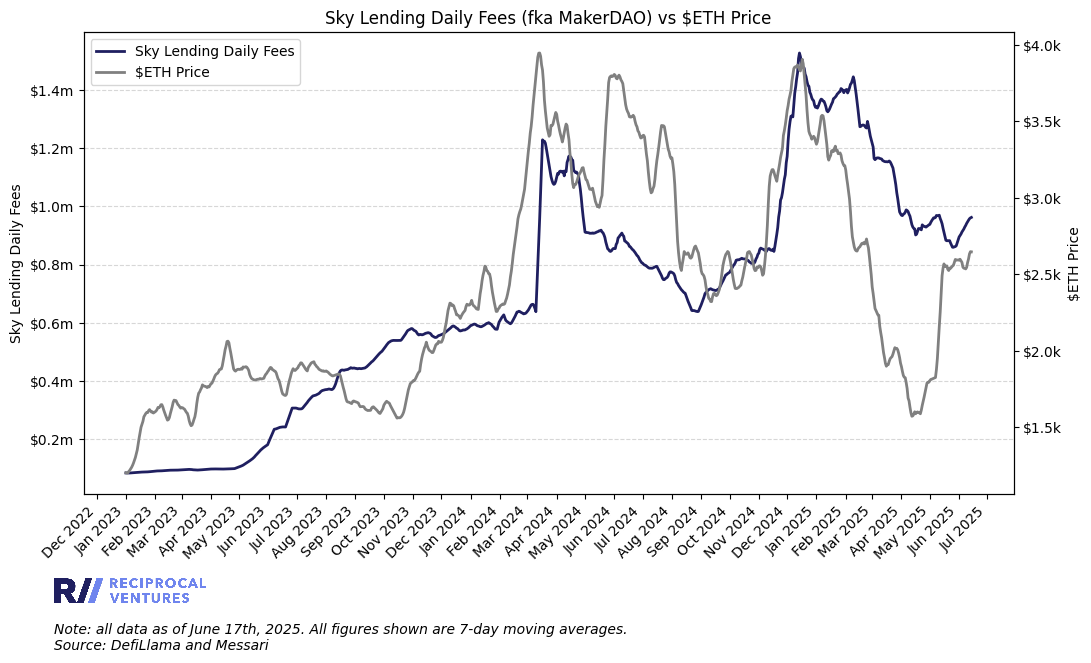

           date  makerdao-fees  makerdao-fees-7d        close  eth-close-7d
1616 2025-06-05         931942     917032.000000  2416.422015   2547.145797
1617 2025-06-06         935977     922269.857143  2478.909918   2539.578262
1618 2025-06-07         947216     929153.714286  2525.944864   2538.832609
1619 2025-06-08         945101     934741.428571  2511.887742   2534.796367
1620 2025-06-09         970110     941662.000000  2681.936808   2545.355699
1621 2025-06-10         964600     947318.714286  2816.309530   2577.097406
1622 2025-06-11         973069     952573.571429  2773.418459   2600.689905
1623 2025-06-12         967224     957613.857143  2644.751265   2633.308369
1624 2025-06-13         956247     960509.571429  2580.262709   2647.787340
1625 2025-06-14         958573     962132.000000  2517.817097   2646.626230


In [35]:
# Load MakerDAO fees data
with open("raw-data/defillama-raw-data/defillama_makerdao-fees.json", "r") as f:
    maker_data = json.load(f)

maker_df = pd.DataFrame(maker_data["totalDataChart"], columns=["timestamp", "makerdao-fees"])
maker_df["date"] = pd.to_datetime(maker_df["timestamp"], unit="s")
maker_df = maker_df[["date", "makerdao-fees"]]

# Calculate trailing 7-day average
maker_df["makerdao-fees-7d"] = maker_df["makerdao-fees"].rolling(window=7).mean()


# Load Ethereium price data
with open('raw-data/messari-raw-data/messari_ethereum_price.json', 'r') as f:
    eth_data = json.load(f)

points = eth_data['data']['points']
eth_df = pd.DataFrame(points, columns=[
    'timestamp',
    'open',
    'high',
    'low',
    'close',
    'volume'
])
eth_df["date"] = pd.to_datetime(eth_df["timestamp"], unit="s")
eth_df = eth_df[['date','close']]

# Calculate trailing 7-day average
eth_df['eth-close-7d'] = eth_df['close'].rolling(window=7).mean()

# Merge datasets
df = pd.merge(maker_df, eth_df, on="date", how="inner")

# Filter the data for a given time period
df = df[df['date'] >= '2023-01-01']

# Begin charting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot MakerDAO data
ax1.plot(df["date"], df["makerdao-fees-7d"], color="#1f1f60", linewidth=2, label="Sky Lending Daily Fees")
ax1.set_ylabel("Sky Lending Daily Fees")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000000:,.1f}m'))

# format x‑axis
ax1.xaxis.set_major_locator(MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# Plot $ETH data
ax2 = ax1.twinx()
ax2.plot(df["date"], df["eth-close-7d"], color="grey", linewidth=2, label="$ETH Price")
ax2.set_ylabel('$ETH Price')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:,.1f}k'))

# Clean up formatting
ax1.set_title("Sky Lending Daily Fees (fka MakerDAO) vs $ETH Price")
ax1.grid(axis='y', linestyle='--', alpha=0.5)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")
add_logo(ax1, position=(0.05, -0.21))
plt.figtext(0.1, -0.15, f"Note: all data as of {date}. All figures shown are 7-day moving averages.\nSource: DefiLlama and Messari", ha='left', fontsize=10, style='italic')

# Save plot
if not os.path.exists("plots"):
    os.makedirs("plots")
plt.savefig(f"{plots_filepath}/makerdao_fees_vs_eth_price.png", dpi=300, bbox_inches='tight')
plt.show()

# Print sample of the dataset with 7D average
print(df.tail(10))

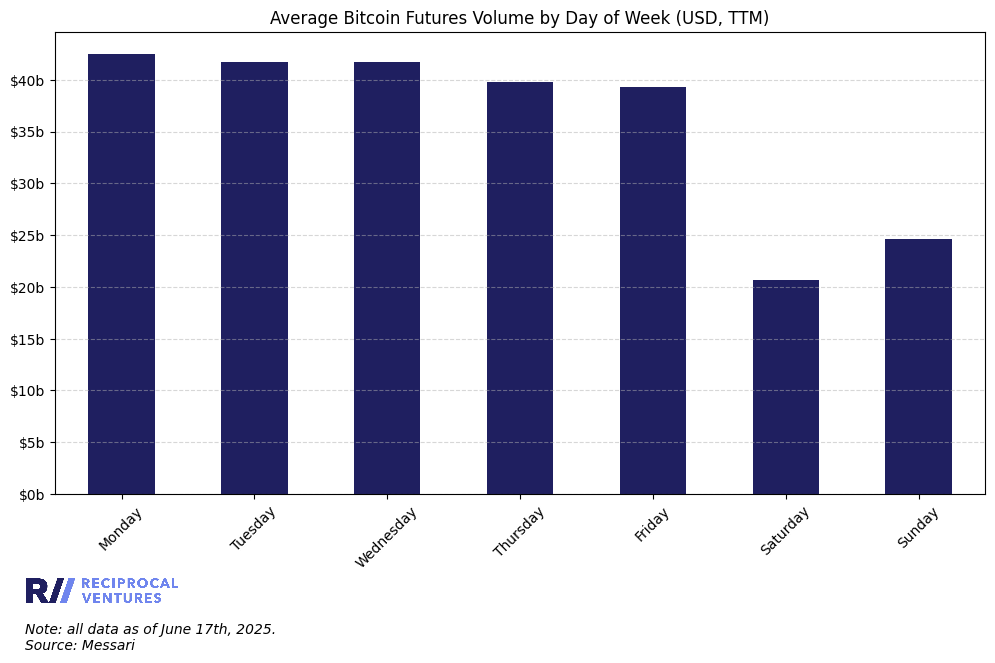

       timestamp  trade_count    volume_usd    volume_btc  volume_other  \
1616  1749081600     26996720  8.857600e+10  4.262985e+10  4.594616e+10   
1617  1749168000     17405296  5.980964e+10  2.930881e+10  3.050082e+10   
1618  1749254400      8252197  2.967258e+10  1.528735e+10  1.438523e+10   
1619  1749340800      8266131  2.772665e+10  1.423929e+10  1.348736e+10   
1620  1749427200     21294978  7.291472e+10  3.818755e+10  3.472716e+10   
1621  1749513600     20568918  5.652671e+10  2.829805e+10  2.822866e+10   
1622  1749600000     18398866  5.150810e+10  2.509428e+10  2.641382e+10   
1623  1749686400     19674403  6.129383e+10  2.938755e+10  3.190628e+10   
1624  1749772800     26006047  7.738178e+10  3.824052e+10  3.914125e+10   
1625  1749859200      7285514  2.003979e+10  9.782284e+09  1.025750e+10   

           date day_of_week  
1616 2025-06-05    Thursday  
1617 2025-06-06      Friday  
1618 2025-06-07    Saturday  
1619 2025-06-08      Sunday  
1620 2025-06-09      Mon

In [36]:
# Load the JSON data
with open('raw-data/messari-raw-data/messari_bitcoin_futures-volume.json', 'r') as f:
    raw = json.load(f)

# Build a DataFrame; adjust column names if yours differ
points = raw['data']['points']
df = pd.DataFrame(points, columns=[
    'timestamp',
    'trade_count',
    'volume_usd',
    'volume_btc',
    'volume_other'
])

# Convert the UNIX timestamp to datetime and extract weekday names
df['date'] = pd.to_datetime(df['timestamp'], unit='s')
df['day_of_week'] = df['date'].dt.day_name()

# Compute the average USD volume for each day of the week
avg_volume = df.groupby('day_of_week')['volume_usd'].mean()

# Reorder the index so days run from Monday to Sunday
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_volume = avg_volume.reindex(weekday_order)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
avg_volume.plot(kind='bar', ax=ax, color="#1f1f60", xlabel='')

# X-axis formatting
plt.xticks(rotation=45)

# Y-axis formatting
ax.set_title("Average Bitcoin Futures Volume by Day of Week (USD, TTM)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000000000:.0f}b'))

plt.grid(axis='y', linestyle='--', alpha=0.5)
add_logo(ax, position=(0.05, -0.21))
plt.figtext(0.1, -0.15, f"Note: all data as of {date}.\nSource: Messari", ha='left', fontsize=10, style='italic')

# Save plot
if not os.path.exists("plots"):
    os.makedirs("plots")
plt.savefig(f"{plots_filepath}/bitcoin-futures-by-day-of-week.png", dpi=300, bbox_inches='tight')
plt.show()

# Print sample of the dataset with 7D average
print(df.tail(10))


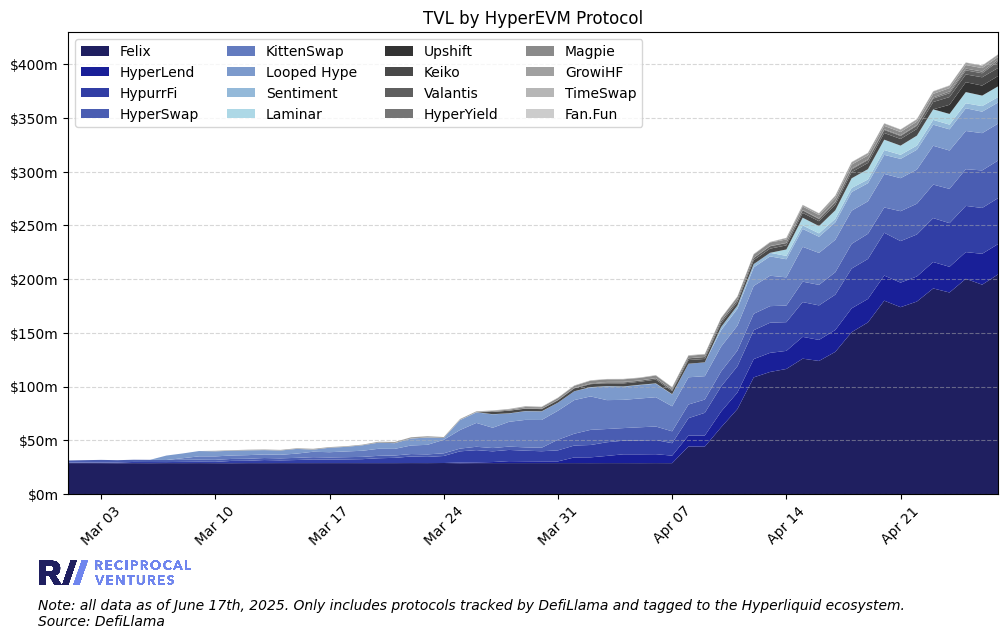

         date         Felix     HyperLend      HypurrFi     HyperSwap  \
58 2025-04-18  1.506011e+08  2.219316e+07  3.704388e+07  2.297480e+07   
59 2025-04-19  1.597420e+08  2.184975e+07  3.723151e+07  2.338966e+07   
60 2025-04-20  1.799465e+08  2.336087e+07  3.986219e+07  2.353479e+07   
61 2025-04-21  1.738997e+08  2.284820e+07  3.865595e+07  2.783859e+07   
62 2025-04-22  1.791495e+08  2.333465e+07  3.910241e+07  2.862491e+07   
63 2025-04-23  1.913409e+08  2.458963e+07  4.088106e+07  3.121266e+07   
64 2025-04-24  1.875745e+08  2.391402e+07  4.063260e+07  3.187275e+07   
65 2025-04-25  2.003139e+08  2.485012e+07  4.301293e+07  3.416021e+07   
66 2025-04-26  1.948459e+08  2.873736e+07  4.266920e+07  3.493229e+07   
67 2025-04-27  2.046497e+08  2.821925e+07  4.275234e+07  3.498771e+07   

      KittenSwap   Looped Hype     Sentiment       Laminar       Upshift  \
58  3.090337e+07  1.732842e+07  3.786980e+06  9.007740e+06  0.000000e+00   
59  3.022498e+07  1.687226e+07  3.447268e+06

In [37]:
import json
import pandas as pd
import matplotlib.pyplot as plt


# define top HyperEVM protocols tracked by DefiLlama (MAKE SURE THIS IS THE SAME LIST USED WHEN PULLING THE RAW DATA)
hyperevm = {
    'felix': "Felix",
    'hyperlend': 'HyperLend',
    'hypurrfi': 'HypurrFi',
    'hyperswap': 'HyperSwap',
    'kittenswap-finance': 'KittenSwap',
    'looped-hype': 'Looped Hype',
    'sentiment': 'Sentiment',
    'laminar': 'Laminar',
    'upshift': 'Upshift',
    'keiko-finance': 'Keiko',
    'valantis': 'Valantis',
    'hyperyield': 'HyperYield',
    'magpie-ecosystem': 'Magpie',
    'growihf': 'GrowiHF',
    'timeswap': 'TimeSwap',
    'fan.fun': 'Fan.Fun'
}

asset_colors = {
    'Felix':      '#1f1f60',
    'HyperLend':  '#191F98',
    'HypurrFi':   '#313EA5',
    'HyperSwap':  '#4A5DB2',
    'KittenSwap': '#637BBF',
    'Looped Hype':'#7C9ACC',
    'Sentiment':  '#94B9D9',
    'Laminar':    '#ADD8E6',
    'Upshift':    '#333333',
    'Keiko':      '#494949',
    'Valantis':   '#5F5F5F',
    'HyperYield': '#757575',
    'Magpie':     '#8A8A8A',
    'GrowiHF':    '#A0A0A0',
    'TimeSwap':   '#B6B6B6',
    'Fan.Fun':    '#CCCCCC'
}

df_master = None

for raw_id, asset in hyperevm.items():
    with open(f'raw-data/defillama-raw-data/hyperevm/defillama_{raw_id}_tvl.json') as f:
        data = json.load(f)
    
    # Select only the two real keys, then rename
    try:
        try:
            raw_df = pd.DataFrame(
                data['chainTvls']['Hyperliquid']['tvl'],
                columns=['date', 'totalLiquidityUSD']
            )
            raw_df.rename(columns={
                'date': 'timestamp',
                'totalLiquidityUSD': asset
            }, inplace=True)
            raw_df['date'] = pd.to_datetime(raw_df['timestamp'], unit='s')
            raw_df = raw_df[['date', asset]]
        except:
            raw_df = pd.DataFrame(
                data['chainTvls']['Hyperliquid L1-borrowed']['tvl'],
                columns=['date', 'totalLiquidityUSD']
            )
            raw_df.rename(columns={
                'date': 'timestamp',
                'totalLiquidityUSD': asset
            }, inplace=True)
            raw_df['date'] = pd.to_datetime(raw_df['timestamp'], unit='s')
            raw_df = raw_df[['date', asset]]
    except:
        raw_df = pd.DataFrame(
                data['chainTvls']['Hyperliquid L1']['tvl'],
                columns=['date', 'totalLiquidityUSD']
            )
        raw_df.rename(columns={
                'date': 'timestamp',
                'totalLiquidityUSD': asset
            }, inplace=True)
        raw_df['date'] = pd.to_datetime(raw_df['timestamp'], unit='s')
        raw_df = raw_df[['date', asset]]

    # Merge dataframes
    df_master = raw_df if df_master is None else df_master.merge(raw_df, on='date', how='outer')
    df_master.fillna(0, inplace=True)
    
# Filter by appropriate dates
df_master = df_master[df_master['date'] >= '2025-03-01']
df_master = df_master[df_master['date'] <= '2025-04-27']

# Make an ordered list of asset names
asset_list = list(hyperevm.values())

# Sort your master dataframe by date
df_master = df_master.sort_values('date')

# Prepare the values and colors in the right order
dates   = df_master['date']
series  = [df_master[asset] for asset in asset_list]
colors  = [asset_colors[asset]   for asset in asset_list]

# Plot a single stacked‐area call
fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(
    dates,
    *series,
    labels=asset_list,
    colors=colors
)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000000:.0f}m'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=4)
plt.grid(axis='y', linestyle='--', alpha=0.5)
add_logo(ax, position=(0.05, -0.17))
ax.margins(x=0)
plt.figtext(0.1, -0.11, f"Note: all data as of {date}. Only includes protocols tracked by DefiLlama and tagged to the Hyperliquid ecosystem.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')
ax.set_title('TVL by HyperEVM Protocol')

# Save plot
if not os.path.exists("plots"):
    os.makedirs("plots")
plt.savefig(f"{plots_filepath}/hyperevm-tvl.png", dpi=300, bbox_inches='tight')
plt.show()

# Print sample of the dataset
print(df_master.tail(10))

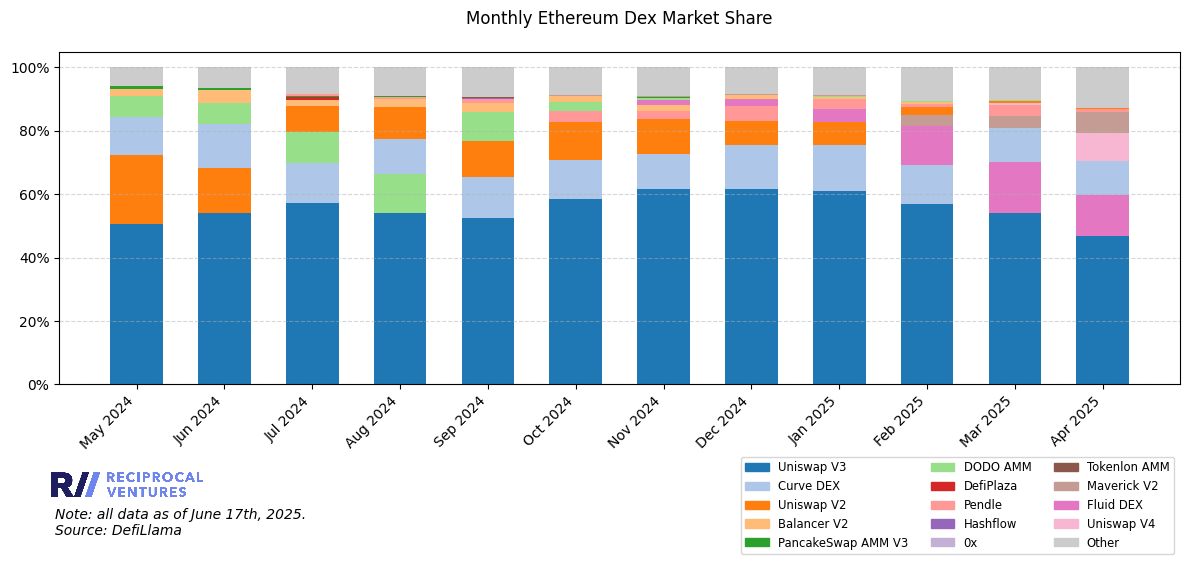

In [38]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import os

# ——— Load the raw JSON breakdown data ———
with open('raw-data/defillama-raw-data/defillama_all-ethereum-dexs.json') as f:
    data = json.load(f)

breakdown = data['totalDataChartBreakdown']

# ——— Build a full daily DataFrame ———
rows = []
for ts, day_vol in breakdown:
    row = {'date': pd.to_datetime(ts, unit='s')}
    row.update(day_vol)
    rows.append(row)

df = pd.DataFrame(rows).fillna(0)

# ——— Filter to your date range ———
df = df[(df['date'] >= '2024-05-01') & (df['date'] <= '2025-04-29')]

# ——— Sort & set date as index ———
df = df.sort_values('date').set_index('date')

# ——— Roll each day into Top 5 + Other ———
daily_agg = []
for dt, row in df.iterrows():
    sorted_row = row.sort_values(ascending=False)
    top5 = sorted_row.iloc[:5]
    other = sorted_row.iloc[5:].sum()
    entry = top5.to_dict()
    entry['Other'] = other
    daily_agg.append(pd.Series(entry, name=dt))

df_top5 = pd.DataFrame(daily_agg).fillna(0)

# ——— Ensure “Other” is the last column ———
all_protocols = [c for c in df_top5.columns if c != 'Other'] + ['Other']
df_top5 = df_top5[all_protocols]

# ——— Aggregate to calendar-month sums (month-end) ———
df_monthly = df_top5.resample('ME').sum()

# ——— If it's a PeriodIndex, convert to timestamps ———
if isinstance(df_monthly.index, pd.PeriodIndex):
    df_monthly.index = df_monthly.index.to_timestamp(how='end')

# ——— Convert each month’s totals into 100% shares ———
df_monthly_pct = df_monthly.div(df_monthly.sum(axis=1), axis=0)

# ——— Prepare a color map: Tab20 for protocols, grey for Other ———
base_colors = plt.cm.tab20.colors
color_map = {
    proto: base_colors[i % len(base_colors)]
    for i, proto in enumerate(all_protocols[:-1])
}
color_map['Other'] = '#CCCCCC'

# ——— Plot manually so each bar’s segments are sorted descending (Other on top) ———
months = df_monthly_pct.index
x = np.arange(len(months))

fig, ax = plt.subplots(figsize=(12, 6))
for xi, month in enumerate(months):
    shares = df_monthly_pct.loc[month]
    # sort protocols descending except Other
    ordered = shares.drop('Other').sort_values(ascending=False).index.tolist()
    ordered.append('Other')
    bottom = 0.0
    for proto in ordered:
        val = shares[proto]
        ax.bar(xi, val, bottom=bottom, color=color_map[proto], width=0.6)
        bottom += val

# ——— X-axis: month labels ———
labels = months.strftime('%b %Y')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')

# ——— Y-axis: pct formatter ———
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# ——— Legend: one patch per protocol ———
handles = [
    mpatches.Patch(color=color_map[p], label=p)
    for p in all_protocols
]
ax.legend(handles=handles,
          loc='upper right',
          bbox_to_anchor=(1, -0.2),
          ncol=3,
          fontsize='small')

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_title('Monthly Ethereum Dex Market Share', pad=20)
add_logo(ax, position=(.06, -0.3))
plt.figtext(.05, 0.1, f"Note: all data as of {date}. \nSource: DefiLlama", ha='left', fontsize=10, style='italic')

plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig(f'{plots_filepath}/eth-dex-monthly-volume-share-descending-stacked.png', dpi=300)
plt.show()


In [39]:
# Funciton for plotting OI vs circulating supply for a given asset


def oi_vs_circulating_mcap_vs_funding_rate(asset_id, asset_name, date):
    # Load price data
    with open(f'raw-data/messari-raw-data/messari_{asset_id}_price.json', 'r') as f:
        price_data = json.load(f)

    points = price_data['data']['points']
    price_df = pd.DataFrame(points, columns=[
    'timestamp',
    'open',
    'high',
    'low',
    'close',
    'volume'
    ])
    price_df["date"] = pd.to_datetime(price_df["timestamp"], unit="s")
    price_df = price_df[['date','close']]

    # Calculate traling 7-dday average
    price_df['close-7d'] = price_df['close'].rolling(window=7).mean()

    # Load supply data
    with open(f'raw-data/messari-raw-data/messari_{asset_id}_supply.json', 'r') as f:
        supply_data = json.load(f)

    points = supply_data['data']['points']
    supply_df = pd.DataFrame(points, columns=[
    'timestamp',
    'circulating-supply',
    'total-supply'
    ])
    supply_df["date"] = pd.to_datetime(supply_df["timestamp"], unit="s")
    supply_df = supply_df[['date','circulating-supply']]

    # Calculate traling 7-dday average
    supply_df['circulating-supply-7d'] = supply_df['circulating-supply'].rolling(window=7).mean()
    
    # Load oi data
    with open(f"raw-data/messari-raw-data/messari_{asset_id}_futures-open-interest.json", "r") as f:
        oi_data = json.load(f)
    
    points = oi_data['data']['points']
    oi_df = pd.DataFrame(points, columns=[
        'timestamp',
        'open-interest'
    ])
    oi_df["date"] = pd.to_datetime(oi_df["timestamp"], unit="s")
    oi_df = oi_df[['date','open-interest']]
    oi_df['open-interest-7d'] = oi_df['open-interest'].rolling(window=7).mean()
    
    # Load mcap data
    with open(f"raw-data/messari-raw-data/messari_{asset_id}_marketcap.json", 'r') as f:
        mcap_data = json.load(f)
    
    points = mcap_data['data']['points']
    mcap_df = pd.DataFrame(points, columns=[
        'timestamp',
        'circulating-marketcap',
        'circulating-marketcap-dominance',
        'fully-diluted-marketcap'
    ])
    mcap_df["date"] = pd.to_datetime(mcap_df["timestamp"], unit="s")
    mcap_df = mcap_df[['date','circulating-marketcap']]
    mcap_df['circulating-marketcap-7d'] = mcap_df['circulating-marketcap'].rolling(window=7).mean()

    # Load fundring rate data
    with open (f'raw-data/messari-raw-data/messari_{asset_id}_futures-funding-rate.json', 'r') as f:
        rate_data = json.load(f)

    points = rate_data['data']['points']
    rate_df = pd.DataFrame(points, columns=[
        'timestamp',
        "funding-rate-open-interest",
        "funding-rate-volume"
    ])
    rate_df['date'] = pd.to_datetime(rate_df['timestamp'], unit='s')
    rate_df = rate_df[['date', 'funding-rate-open-interest']]
    rate_df['funding-rate-open-interest-7d'] = rate_df['funding-rate-open-interest'].rolling(window=7).mean()
    
    # Merge datasets
    step1_df = pd.merge(price_df, supply_df, on="date", how="inner")
    step2_df = pd.merge(step1_df, oi_df, on='date', how='inner')
    step3_df = pd.merge(step2_df, mcap_df, on='date', how='inner')
    df = pd.merge(step3_df, rate_df, on='date', how='inner')
    df['oi_as_%_circ_mcap'] = df['open-interest'] / df['circulating-marketcap'] * 100 # Multiply by 100 to convert to % terms
    df['oi_as_%_circ_mcap_7d'] = df['oi_as_%_circ_mcap'].rolling(window=7).mean()
    
    # Drop any rows without a full 7‑day average, plus the very last day
    plot_df = df[df["open-interest-7d"].notna()].iloc[:-1]
    
    # two rows: top for MCap + OI, bottom for funding rates
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        figsize=(12, 8),
        sharex=True,
        gridspec_kw={'height_ratios': [3, 1],
                    'hspace':0.05}
    )

    # TOP PANEL: Circulating Market Cap (area) + Open Interest (line)

    # area: 7-day MCap
    ax_top.fill_between(
        plot_df["date"],
        plot_df["close"],
        color="#a4a2a8", alpha=1,
        label="Close Price"
    )
    ax_top.set_ylabel("Close Price")
    ax_top.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'${x:,.2f}')
    )
    ax_top.set_ylim(0)

    # line: 7-day OI on a second y-axis
    ax_oi = ax_top.twinx()
    ax_oi.plot(
        plot_df["date"],
        plot_df["circulating-supply"],
        color="#1f1f60", linewidth=2,
        label="Circulating Supply"
    )
    ax_oi.set_ylabel("Circulating Supply")
    ax_oi.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'{x/1e6:,.0f}m')
    )
    ax_oi.set_ylim(0)

    # date formatting
    ax_top.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax_top.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax_top.get_xticklabels(), rotation=45, ha="right")


    # BOTTOM PANEL: Funding Rate (OI-weighted)

    ax_bot.plot(
        plot_df['date'],
        plot_df['funding-rate-open-interest'],
        color="black", linewidth=1.2,
        label="Funding Rate"
    )
    ax_bot.set_ylabel("Funding Rate")
    ax_bot.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'{x*10000:,.0f}bps')
    )
    
    # line: add OI as % of Circ. Mcap to bottom chart
    ax_perc = ax_bot.twinx()
    ax_perc.plot(
        plot_df["date"],
        plot_df["oi_as_%_circ_mcap"],
        color="red", linewidth=1.2,
        label="OI as % of Circ. Mcap"
    )
    ax_perc.set_ylabel("OI (% Circ. Mcap)")
    ax_perc.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'{x:,.0f}%')
    )
    ax_perc.set_ylim(0)

    # 1) remove horizontal margins
    ax_top.margins(x=0)
    ax_bot.margins(x=0)

    # 3) bottom axis: month & two-digit year
    from matplotlib.dates import MonthLocator, DateFormatter

    ax_bot.xaxis.set_major_locator(MonthLocator())
    ax_bot.xaxis.set_major_formatter(DateFormatter("%b %y"))
    plt.setp(ax_bot.get_xticklabels(), rotation=45, ha="right")

     # ─── TITLES ───
    ax_top.set_title(f"{asset_name}: Price, Circulating Supply, and Open Interest", fontsize=14)

    # Pull legend handles from both axes
    h1, l1 = ax_top.get_legend_handles_labels()
    h2, l2 = ax_oi.get_legend_handles_labels()
    h3, l3 = ax_bot.get_legend_handles_labels()
    h4, l4 = ax_perc.get_legend_handles_labels()
    handles = h1 + h2 + h3 + h4
    labels  = l1 + l2 + l3 + l4

    # ─── make room at the bottom ───
    fig.subplots_adjust(bottom=0.2)

    # ─── FIGURE‐LEVEL LEGEND ───
    legend = fig.legend(
        handles, labels,
        loc="lower center",
        ncol=2,
        frameon=True,
        bbox_to_anchor=(0.5, 0.06),
        fontsize=10
    )
    # give it a thin black border
    frame = legend.get_frame()
    frame.set_edgecolor("black")
    frame.set_linewidth(0.5)
    frame.set_alpha(1)

    # ─── SMALLER LOGO, ALIGNED TO THE LEFT ───
    # position is in axis‐coordinates of ax_bot: x=0.075, y slightly below the axis
    add_logo(ax_bot, position=(0.075, -0.6), zoom=0.1)

    # ─── FOOTNOTE, SAME LEFT MARGIN ───
    fig.text(
        0.12, 0.03,
        f"Note: all data as of {date}.\nFunding rate is OI-weighted.\nSource: Messari",
        ha="left",
        fontsize=8,
        style="italic"
    )

    plt.savefig(
        f"{plots_filepath}/{asset_name}_price_vs_circ-supply_vs_funding-rate_vs_oi.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    print(plot_df.tail(5))

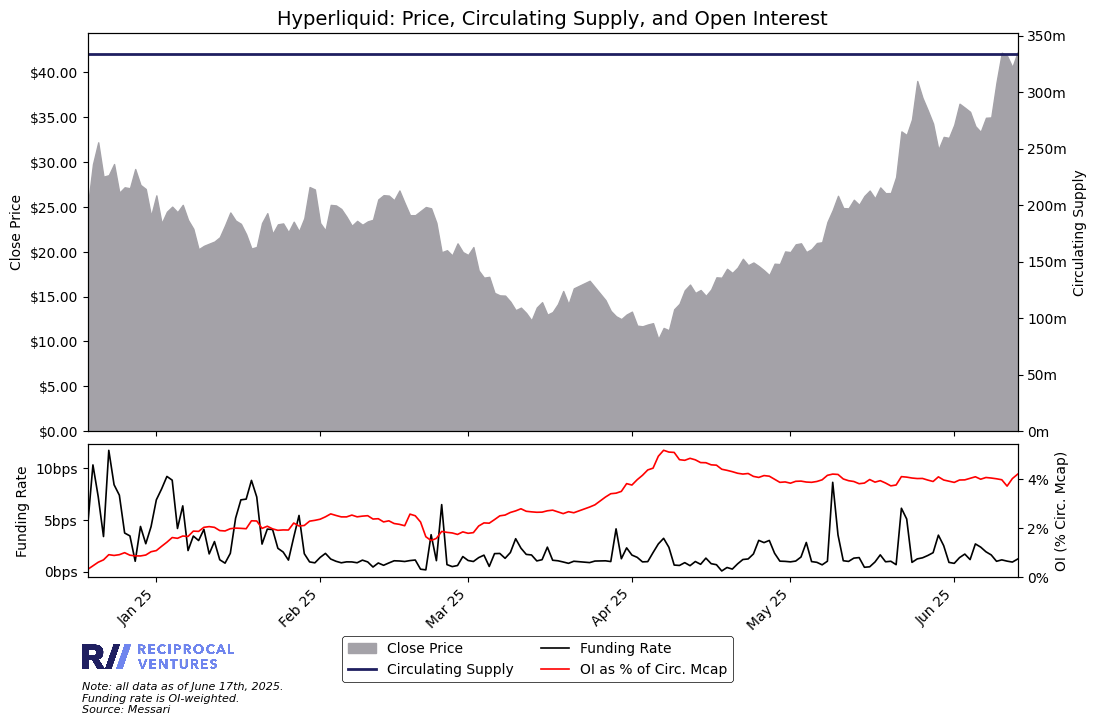

          date      close   close-7d  circulating-supply  \
169 2025-06-09  38.891115  35.402214           333928180   
170 2025-06-10  42.193474  36.278223           333928180   
171 2025-06-11  41.833628  37.168839           333928180   
172 2025-06-12  40.568075  38.107921           333928180   
173 2025-06-13  42.273235  39.381287           333928180   

     circulating-supply-7d  open-interest  open-interest-7d  \
169            333928180.0   5.191917e+08      4.745921e+08   
170            333928180.0   5.576664e+08      4.862548e+08   
171            333928180.0   5.167616e+08      4.918527e+08   
172            333928180.0   5.426622e+08      5.032198e+08   
173            333928180.0   5.907462e+08      5.242788e+08   

     circulating-marketcap  circulating-marketcap-7d  \
169            12986839297              1.182180e+10   
170            14089589837              1.211432e+10   
171            13969427401              1.241172e+10   
172            13546823301          

In [40]:
assets = {'hyperliquid': 'Hyperliquid'}

for asset_id, asset_name in assets.items():
    oi_vs_circulating_mcap_vs_funding_rate(asset_id, asset_name, date)

In [41]:
def annualized_revenue_vs_price_to_annualized_revenue(asset_id, asset_name, start_date, date):
    # Load revenue data
    with open(f"raw-data/defillama-raw-data/defillama_{asset_id}-revenue.json", "r") as f:
        rev_data = json.load(f)
    
    rev_df = pd.DataFrame(rev_data["totalDataChart"], columns=["timestamp", "revenue"])
    rev_df["date"] = pd.to_datetime(rev_df["timestamp"], unit="s")
    rev_df = rev_df[["date", "revenue"]]
    
    # Annualize revenue and calculate trailing 7-day average
    rev_df['annualized-revenue'] = rev_df['revenue'] * 365
    rev_df["annualized-revenue-7d"] = rev_df["annualized-revenue"].rolling(window=7).mean()

    # Load mcap data
    with open(f"raw-data/messari-raw-data/messari_{asset_id}_marketcap.json", 'r') as f:
        mcap_data = json.load(f)
    
    points = mcap_data['data']['points']
    mcap_df = pd.DataFrame(points, columns=[
        'timestamp',
        'circulating-marketcap',
        'circulating-marketcap-dominance',
        'fully-diluted-marketcap'
    ])
    mcap_df["date"] = pd.to_datetime(mcap_df["timestamp"], unit="s")
    mcap_df = mcap_df[['date','fully-diluted-marketcap']]
    mcap_df['FDV-7d'] = mcap_df['fully-diluted-marketcap'].rolling(window=7).mean()
    
    # Merge datasets
    df = pd.merge(rev_df, mcap_df, on="date", how="inner")
    
    # Calculate P/S ratio and trailing 7-day average
    df['FDV-to-annualized-revenue-multiple'] = df['fully-diluted-marketcap'] / df['annualized-revenue']
    df['FDV-to-annualized-revenue-multiple-7d'] = df['FDV-to-annualized-revenue-multiple'].rolling(window=7).mean()

    # Filter the data for a given time period
    plot_df = df[df['date'] >= start_date]
    
    # 6) Plot
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Area: Hyperliquid market share
    ax1.fill_between(
        plot_df["date"], plot_df["annualized-revenue-7d"],
        color="#a4a2a8", alpha=1,
        label="Annualized Revenue"
    )
    ax1.set_ylabel("Annualized Revenue")
    ax1.set_ylim(bottom=0)
    ax1.yaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f'${x/1e9:,.0f}b'))
    
    # Monthly ticks, lighter crowding
    ax1.xaxis.set_major_locator(YearLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")
    
    # Line: FDV / annualzied revenue
    ax2 = ax1.twinx()
    ax2.plot(
        plot_df["date"], plot_df["FDV-to-annualized-revenue-multiple-7d"],
        color="#1f1f60", linewidth=2,
        label="FDV / Annualized Revenue"
    )
    ax2.set_ylabel("FDV / Annualized Revenue")
    ax2.set_ylim(bottom=0)
    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}x'))

    # no extra padding
    ax1.margins(x=0)
    
    # Title, grid & legend
    ax1.set_title(f"{asset_name}: Annualized Revenue vs. FDV / Annualized Revenue", fontsize=14)
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")
    
    # Save & show
    add_logo(ax1, position=(0.075, -0.21))
    plt.figtext(0.075, -0.04, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama and Messari", ha='left', fontsize=10, style='italic')
    plt.tight_layout()
    plt.savefig(f"{plots_filepath}/{asset_id}-annualized-revenue_vs_FDV-to-annualized-revenue_7d.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    # Debug print
    print(df.tail(10))

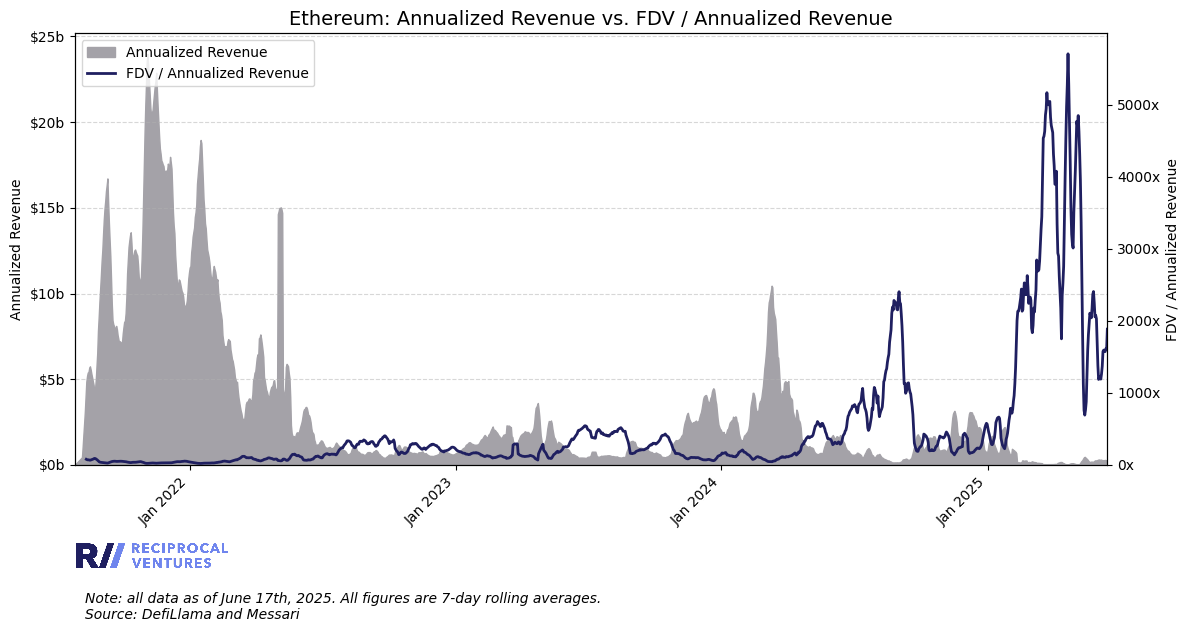

           date  revenue  annualized-revenue  annualized-revenue-7d  \
1400 2025-06-05  1330433           485608045           3.174608e+08   
1401 2025-06-06   638918           233205070           2.946389e+08   
1402 2025-06-07   294647           107546155           2.890794e+08   
1403 2025-06-08   228684            83469660           2.810721e+08   
1404 2025-06-09   823311           300508515           2.766422e+08   
1405 2025-06-10  1291542           471412830           2.894948e+08   
1406 2025-06-11  1054595           384927175           2.952396e+08   
1407 2025-06-12   975018           355881570           2.767073e+08   
1408 2025-06-13   718428           262226220           2.808532e+08   
1409 2025-06-14   173161            63203765           2.745185e+08   

      fully-diluted-marketcap        FDV-7d  \
1400             2.917176e+11  3.075013e+11   
1401             2.992604e+11  3.065869e+11   
1402             3.049372e+11  3.064960e+11   
1403             3.032431e+11 

In [42]:
assets = {'ethereum': 'Ethereum'}
start_date = '2021-01-01'

for asset_id, asset_name in assets.items():
    annualized_revenue_vs_price_to_annualized_revenue(asset_id, asset_name, start_date, date)

In [43]:
# Funciton for plotting OI as % FDV for a given asset and comparing to BTC

def price_vs_oi(asset_id, asset_name, date):
    # Load price data
    with open(f'raw-data/messari-raw-data/messari_{asset_id}_price.json', 'r') as f:
        price_data = json.load(f)
    
    points = price_data['data']['points']
    price_df = pd.DataFrame(points, columns=[
        'timestamp',
        'open',
        'high',
        'low',
        'close',
        'volume'
    ])
    price_df["date"] = pd.to_datetime(price_df["timestamp"], unit="s")
    price_df = price_df[['date','close']]
    
    # Calculate trailing 7-day average
    price_df['close-7d'] = price_df['close'].rolling(window=7).mean()

    # Load fundring rate data for the asset slug
    with open (f'raw-data/messari-raw-data/messari_{asset_id}_futures-open-interest.json', 'r') as f:
        rate_data = json.load(f)

    points = rate_data['data']['points']
    oi_df = pd.DataFrame(points, columns=[
        'timestamp',
        "open-interest"
    ])
    oi_df['date'] = pd.to_datetime(oi_df['timestamp'], unit='s')
    oi_df = oi_df[['date', 'open-interest']]
    oi_df = oi_df.rename(columns={"open-interest": "oi"})
     # Calculate trailing 7-day average
    oi_df['oi-7d'] = oi_df['oi'].rolling(window=7).mean()

    # Merge datasets for asset slug
    df = pd.merge(price_df, oi_df, on="date", how="inner")

    # 6) Plot
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Area: Price
    ax1.fill_between(
        df["date"], df["close-7d"],
        color="#a4a2a8", alpha=1,
        label=f"{asset_name} Price"
    )
    ax1.yaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    
    ax1.set_ylabel("Price")
    ax1.margins(x=0)                  # no extra padding
    ax1.set_ylim(bottom=0)

    # Monthly ticks, lighter crowding
    ax1.xaxis.set_major_locator(MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
  
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")
    
    # Line: OI
    ax2 = ax1.twinx()
    ax2.plot(
        df["date"], df["oi-7d"],
        color="#1f1f60", linewidth=2,
        label=f"{asset_name} OI"
    )
    ax2.set_ylabel("OI")
    ax2.yaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f'${x/1e6:,.0f}m'))
    
    # Title, grid & legend
    ax1.set_title(f"{asset_name}: Price vs OI", fontsize=14)
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")
    
    # Save & show
    add_logo(ax1, position=(0.075, -0.21))
    plt.figtext(0.075, -0.04, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: Messari", ha='left', fontsize=10, style='italic')
    plt.tight_layout()
    plt.savefig(f"{plots_filepath}/{asset_id}_price_vs_oi_7d.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    # Debug print
    print(df.tail(5))

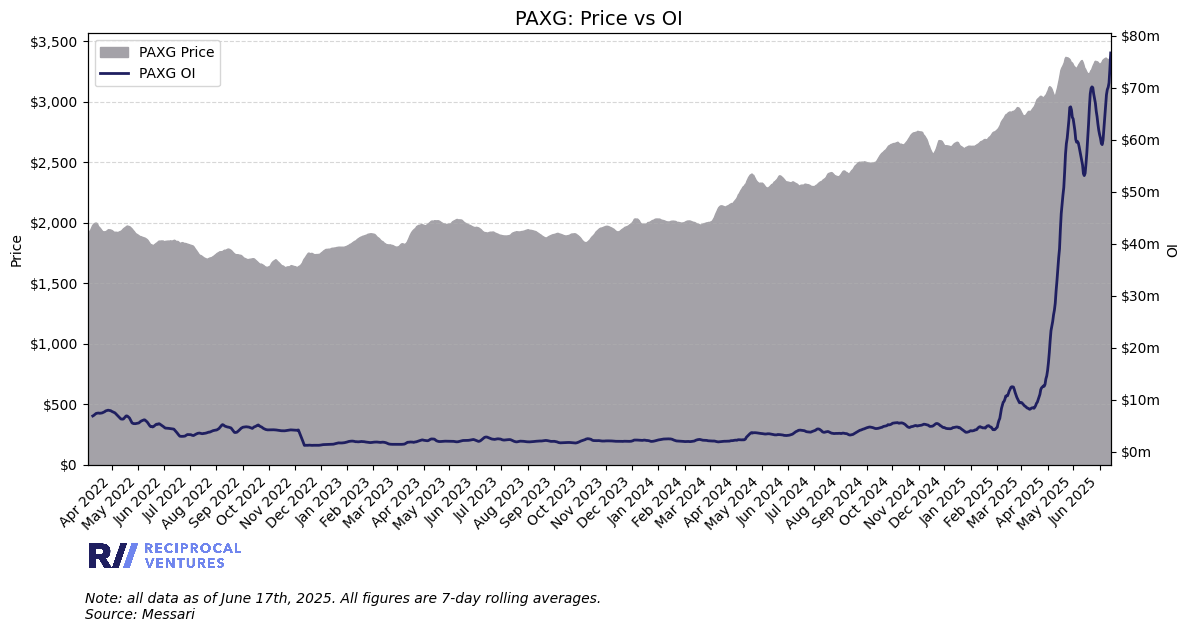

           date        close     close-7d            oi         oi-7d
1195 2025-06-10  3340.837619  3354.880142  6.684521e+07  6.967331e+07
1196 2025-06-11  3379.915686  3353.158628  6.393298e+07  7.009233e+07
1197 2025-06-12  3409.014237  3356.731189  7.158033e+07  7.094892e+07
1198 2025-06-13  3463.522306  3374.660945  9.230287e+07  7.354460e+07
1199 2025-06-14  3486.475597  3396.349033  9.352550e+07  7.671046e+07


In [44]:
assets = {'pax-gold': 'PAXG'}

for asset_id, asset_name in assets.items():
    price_vs_oi(asset_id, asset_name, date)

In [45]:
# Function for plotting revenue or fees / mcap or fdv charts for a set of assets

def revenue_vs_tvl_asset(start_date, assets, breakout_asset, bottom_metric, top_metric, category_title):
    df_master = None
    # Load revenue and FDV data
    for asset_slug, asset_name in assets.items():
        rev_path = f"raw-data/defillama-raw-data/daily{bottom_metric}_data/{asset_slug}_{bottom_metric}.json"
        with open(rev_path) as rev_f:
            rev_data = json.load(rev_f)
    
        rev_df = pd.DataFrame(rev_data["totalDataChart"], columns=["timestamp", f"{asset_slug}-{bottom_metric}"])
        rev_df["date"] = pd.to_datetime(rev_df["timestamp"], unit="s")
        rev_df[f"{asset_slug}-annualized-{bottom_metric}"] = rev_df[f"{asset_slug}-{bottom_metric}"] * 365
        rev_df = rev_df[["date", f"{asset_slug}-annualized-{bottom_metric}"]]

        # Load fdv data
        fdv_path = f'raw-data/messari-raw-data/messari_{asset_slug}_marketcap.json'
        with open(fdv_path) as fdv_f:
            fdv_data = json.load(fdv_f)
        
        points = fdv_data['data']['points']
        fdv_df = pd.DataFrame(points, columns=[
            'timestamp',
            'circulating-marketcap',
            'circulating-marketcap-dominance',
            'fully-diluted-marketcap'
        ])
        fdv_df["date"] = pd.to_datetime(fdv_df["timestamp"], unit="s")
        if top_metric == 'FDV':
            fdv_df = fdv_df[['date','fully-diluted-marketcap']]
            fdv_df.rename(columns={'fully-diluted-marketcap': f'{asset_slug}-{top_metric}'}, inplace=True)

        if top_metric == 'MCAP':
            fdv_df = fdv_df[['date','circulating-marketcap']]
            fdv_df.rename(columns={'circulating-marketcap': f'{asset_slug}-{top_metric}'}, inplace=True)
        
        # Merge datasets for a given asset
        interim_df = pd.merge(rev_df, fdv_df, on="date", how="inner")
        
        # Calculate multiple
        interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple'] = interim_df[f'{asset_slug}-{top_metric}'] / interim_df[f'{asset_slug}-annualized-{bottom_metric}']
        interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple-7d'] = interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple'].rolling(window=7).mean()
        
        # Merge asset dataframe into the master dataframe
        df_master = interim_df if df_master is None else df_master.merge(interim_df, on="date", how="outer")
        df_master = df_master.sort_values("date").reset_index(drop=True)

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    
    # define which asset to exclude
    exclude = breakout_asset[0]
    
    # only include the others
    fdv_cols = [
        f"{slug}-{top_metric}"
        for slug in assets
        if slug != exclude
    ]
    mult_cols = [
        f"{slug}-{top_metric}-to-annualized-{bottom_metric}-multiple"
        for slug in assets
        if slug != exclude
    ]
    
    # per-row FDV denominator
    fdv_den = df_master[fdv_cols].sum(axis=1)
    
    # row-wise weights for each FDV column
    weights = df_master[fdv_cols].div(fdv_den, axis=0)
    
    # compute each asset’s weighted term
    weighted_terms = []
    for fdv_col, mult_col in zip(fdv_cols, mult_cols):
        term = weights[fdv_col] * df_master[mult_col]
        weighted_terms.append(term)
    
    # sum them to get your per-day FDV-weighted average
    df_master[f'{top_metric}_weighted_avg_multiple'] = sum(weighted_terms)

    df_master[f'{top_metric}_weighted_avg_multiple-7d'] = df_master[f'{top_metric}_weighted_avg_multiple'].rolling(window=7).mean()
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors
    for asset_slug, asset_name in assets.items():
        ax.plot(
            df_master['date'], 
            df_master[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple-7d'], 
            label=asset_name, 
            linewidth=2
        )
    
    # Setting labels and title
    ax.set_title(f'{category_title}: {top_metric} / Annualized {bottom_metric} (Log Scale)')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}x'))
    ax.set_ylim(1, 10000)

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))
    
    # Add sources and note
    text_box = ax.text(0, -0.27, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama and Messari.",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Center the legend below the chart
    plt.legend(title=f'Select {category_title}', bbox_to_anchor=(0.85, -0.13), loc='upper center', ncol=2)
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{category_title} multiples.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

    # Calculate statistical percentiles for multiple
    median_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].median(), 0)
    percentile_80_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.80),0)
    percentile_20_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.20),0)
    latest_cohort_multiple = round(df_master[f'{top_metric}_weighted_avg_multiple'].dropna().iloc[-1],0)
    median_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].median(), 0)
    percentile_80_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].quantile(0.80),0)
    percentile_20_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].quantile(0.20),0)
    latest_breakout_multiple = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].dropna().iloc[-1],0)

    stats_cohort = {
        "median_multiple": median_cohort,
        "80th_percentile_multiple": percentile_80_cohort,
        "20th_percentile_multiple": percentile_20_cohort,
        'latest_multiple': latest_cohort_multiple
    }

    stats_breakout = {
        "median_multiple": median_breakout,
        "80th_percentile_multiple": percentile_80_breakout,
        "20th_percentile_multiple": percentile_20_breakout,
        'latest_multiple': latest_breakout_multiple
    }
    
    # Print results in human-readable format
    print()
    print(f"{category_title} {top_metric} / Annualized {bottom_metric} Statistics (Excluding {breakout_asset[1]}):")
    print(f"Median {top_metric} / Annualized {bottom_metric}: {median_cohort:,.0f}x")
    print(f"80th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_80_cohort:,.0f}x")
    print(f"20th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_20_cohort:,.0f}x")
    print(f"Latest Multiple: {latest_cohort_multiple:,.0f}x")
    print()
    print(f"{breakout_asset[1]} {top_metric} / Annualized {bottom_metric} Statistics:")
    print(f"Median {top_metric} / Annualized {bottom_metric}: {median_breakout:,.0f}x")
    print(f"80th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_80_breakout:,.0f}x")
    print(f"20th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_20_breakout:,.0f}x")
    print(f"Latest Multiple: {latest_breakout_multiple:,.0f}x")
    print()

    return stats_cohort, stats_breakout

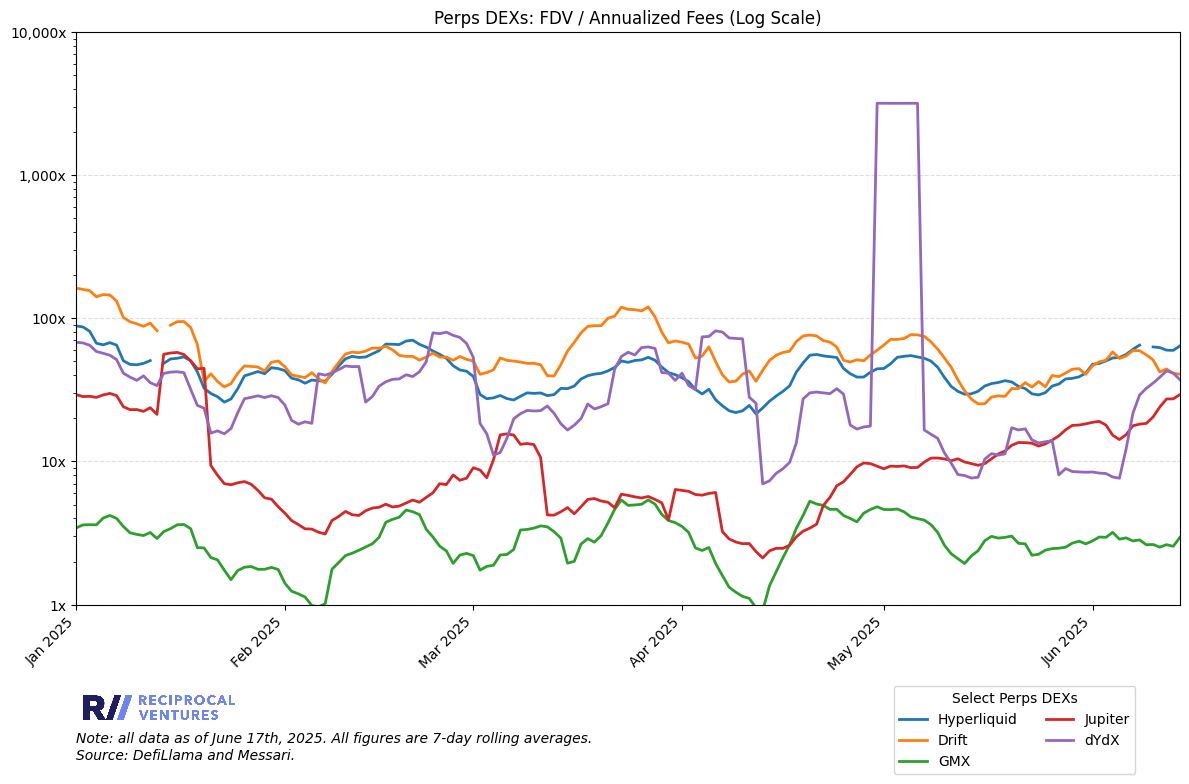


Perps DEXs FDV / Annualized Fees Statistics (Excluding Hyperliquid):
Median FDV / Annualized Fees: 14x
80th Percentile FDV / Annualized Fees: 24x
20th Percentile FDV / Annualized Fees: 10x
Latest Multiple: 46x

Hyperliquid FDV / Annualized Fees Statistics:
Median FDV / Annualized Fees: 38x
80th Percentile FDV / Annualized Fees: 58x
20th Percentile FDV / Annualized Fees: 26x
Latest Multiple: 80x



In [46]:
# Call the function for perp dexs
perps_dexs = {'hyperliquid': 'Hyperliquid',
          'drift': 'Drift',
          'gmx': 'GMX',
          'jupiter': 'Jupiter',
              'dydx': 'dYdX'
         }

# 'bottom_metric' should be 'Fees' or 'Revenue'; 'top_metric' should be 'FDV' or 'MCAP'
start_date = '2025-01-01'
assets = perps_dexs
breakout_asset = ('hyperliquid', 'Hyperliquid')
bottom_metric = 'Fees'
top_metric = 'FDV'
category_title = 'Perps DEXs'

perps_stats, breakout_stats = revenue_vs_tvl_asset(
    start_date     = start_date,
    assets         = perps_dexs,
    breakout_asset = breakout_asset,
    bottom_metric  = bottom_metric,
    top_metric     = top_metric,
    category_title = category_title
)

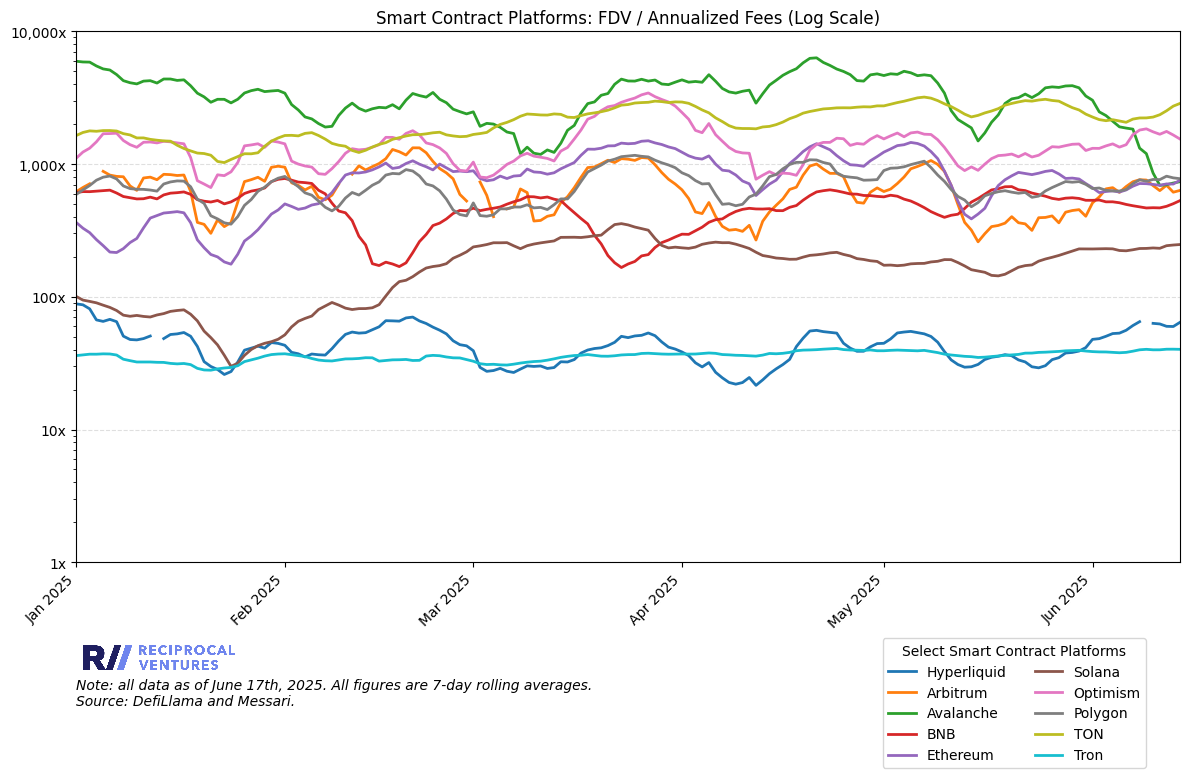


Smart Contract Platforms FDV / Annualized Fees Statistics (Excluding Hyperliquid):
Median FDV / Annualized Fees: 640x
80th Percentile FDV / Annualized Fees: 956x
20th Percentile FDV / Annualized Fees: 443x
Latest Multiple: 1,216x

Hyperliquid FDV / Annualized Fees Statistics:
Median FDV / Annualized Fees: 38x
80th Percentile FDV / Annualized Fees: 58x
20th Percentile FDV / Annualized Fees: 26x
Latest Multiple: 80x



In [47]:
# Call the function for smart contract platforms
smart_contract_platforms = {'hyperliquid': 'Hyperliquid',
          'arbitrum': 'Arbitrum',
          'avalanche': 'Avalanche',
          'bnb': 'BNB',
          'ethereum': 'Ethereum',
          'solana': 'Solana',
          'optimism': 'Optimism',
          'polygon': 'Polygon',
          'ton': 'TON',
          'tron': 'Tron'
             }

# 'bottom_metric' should be 'Fees' or 'Revenue'; 'top_metric' should be 'FDV' or 'MCAP'
assets = smart_contract_platforms
category_title = 'Smart Contract Platforms'

scp_stats, _ = revenue_vs_tvl_asset(
    start_date     = start_date,
    assets         = smart_contract_platforms,
    breakout_asset = breakout_asset,
    bottom_metric  = bottom_metric,
    top_metric     = top_metric,
    category_title = category_title
)

In [48]:
start_date = format_date_with_suffix(start_date)

combined_stats = pd.DataFrame({
    f'{breakout_asset[1]}':              breakout_stats,
    'Perps DEXs':                perps_stats,
    'Smart Contract Platforms': scp_stats

})

combined_stats.index = [
    'Median',
    '80th Percentile',
    '20th Percentile',
    'Most Recent'
]

styled = (
    combined_stats
      .style
      .set_caption(f"{top_metric} / Annualized {bottom_metric} Multiples by Cohort")
      .set_table_styles([
          {"selector": "caption",
           "props": [
             ("font-weight", "bold"),
             ("caption-side", "top"),
             ("text-decoration", "underline")
           ]},
          {"selector": "thead th", "props": [("font-weight", "normal")]},
          {"selector": "tbody th", "props": [("font-weight", "normal")]}
      ], overwrite=False)
      .format(lambda v: f"{v:,.0f}x" if pd.notnull(v) else "")
)

display(styled)


print(f"""
Notes:
 • All data from {start_date} to {date}.
 • Perp DEXs includes: Drift, dYdX, GMX, and Jupiter.
 • Smart Contract Platforms includes: Arbitrum, Avalanche,
   BNB, Ethereum, Solana, Optimism, Polygon, TON, and Tron.
 • Perps DEXs and Smart Contract Platforms multiples are
   daily FDV-weighted averages of all listed protocols.
 
 Sources: DefiLlama and Messari.
""")

,Hyperliquid,Perps DEXs,Smart Contract Platforms
Median,38x,14x,640x
80th Percentile,58x,24x,956x
20th Percentile,26x,10x,443x
Most Recent,80x,46x,"1,216x"



Notes:
 • All data from January 1st, 2025 to June 17th, 2025.
 • Perp DEXs includes: Drift, dYdX, GMX, and Jupiter.
 • Smart Contract Platforms includes: Arbitrum, Avalanche,
   BNB, Ethereum, Solana, Optimism, Polygon, TON, and Tron.
 • Perps DEXs and Smart Contract Platforms multiples are
   daily FDV-weighted averages of all listed protocols.
 
 Sources: DefiLlama and Messari.



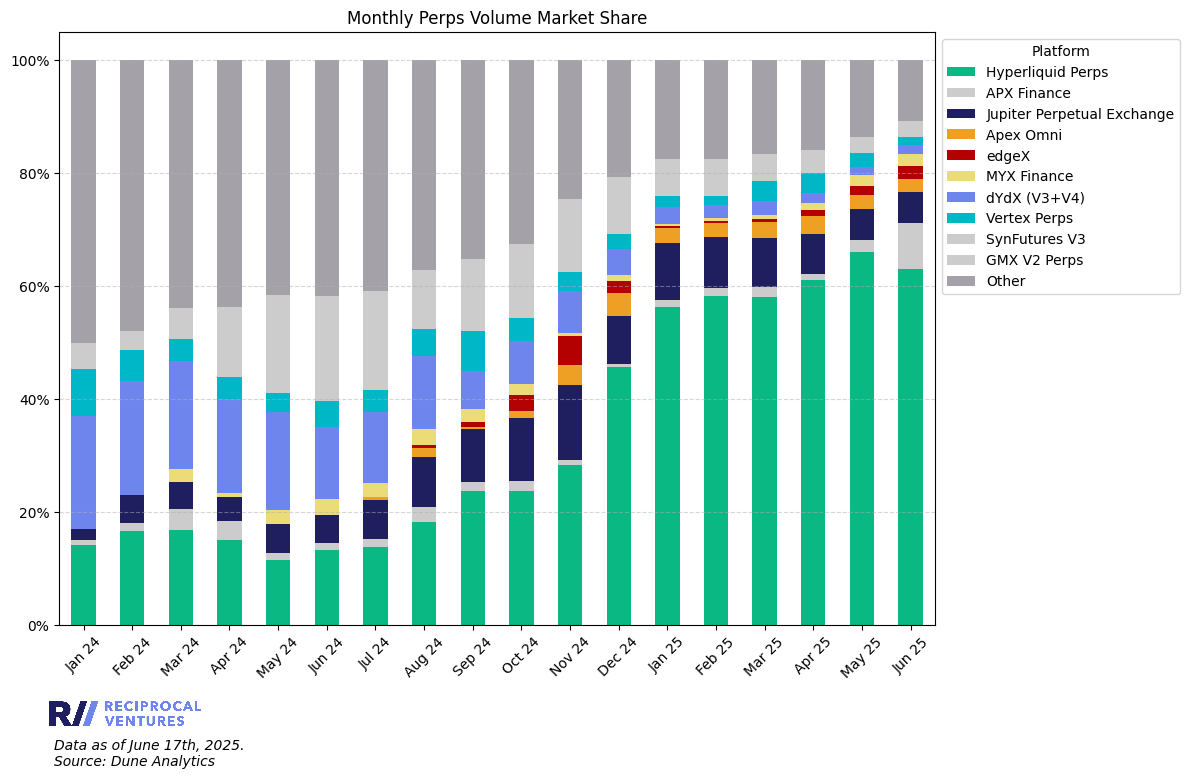

product_name               Hyperliquid Perps   APX Finance  \
week                                                         
2024-09-30 00:00:00+00:00       3.767591e+10  2.682252e+09   
2024-10-31 00:00:00+00:00       2.916287e+10  2.252178e+09   
2024-11-30 00:00:00+00:00       7.432723e+10  2.598869e+09   
2024-12-31 00:00:00+00:00       1.709148e+11  1.716384e+09   
2025-01-31 00:00:00+00:00       2.085117e+11  4.493861e+09   
2025-02-28 00:00:00+00:00       1.835806e+11  4.418462e+09   
2025-03-31 00:00:00+00:00       1.898171e+11  5.307355e+09   
2025-04-30 00:00:00+00:00       1.662562e+11  2.899296e+09   
2025-05-31 00:00:00+00:00       2.360760e+11  7.689828e+09   
2025-06-30 00:00:00+00:00       2.501229e+10  3.280698e+09   

product_name               Jupiter Perpetual Exchange     Apex Omni  \
week                                                                  
2024-09-30 00:00:00+00:00                1.492605e+10  6.144230e+08   
2024-10-31 00:00:00+00:00                1

In [49]:
# Color utils
color_palette = {'Hyperliquid':'#09b882','Bold Blue':'#1f1f60', 'Sky Blue':'#6f85ee', 'Solana Purple':'#9945FF','Engage Orange':'#eda024', 'Dark Slate':'#262935', 'Mauve':'#7c1158', 'Yellow':'#ebdc78', 'Green':'#00b7c7', 'Red':'#b30000','Mid Grey':'#54504c','Other Grey':'#a4a2a8', 'Pure Grey': '#808080','Lighter Grey': '#A9A9A9','Lightest Grey': '#D3D3D3','blue 1':'#03045e', 'blue 2':'#0077b6', 'blue 3':'#00b4d8', 'blue 4':'#90e0ef', 'blue 5':'#caf0f8'}
platform_colors = {
        'Felix': color_palette['Sky Blue'],  
        'Hyperliquid': color_palette['Hyperliquid'],  
        'Jupiter': color_palette['Bold Blue'],      
        'dYdX v4': color_palette['Sky Blue'],      
        'ApeX': color_palette['Engage Orange'],         
        'Holdstation': color_palette['Yellow'],  
        'Vertex Protocol': color_palette['Green'], 
        'GMX': color_palette['Red'],          
        'dYdX v3': color_palette['Dark Slate'],      
        'Drift Protocol': color_palette['Mauve'],
        'RabbitX': color_palette['Mid Grey'],           
        'dYdX': color_palette['Dark Slate'],
        'Gains Network': color_palette['Mauve'],
        'KTX Finance': color_palette['Yellow'],
        'RabbitX': color_palette['Pure Grey'],
        'Aevo': color_palette['Lighter Grey'],
        'Other': color_palette['Other Grey'],
        'Hyperliquid Perps': color_palette['Hyperliquid'],
        'Jupiter Perpetual Exchange': color_palette['Bold Blue'],
        'Vertex Perps': color_palette['Green'],
        'Apex Omni': color_palette['Engage Orange'],
        'MYX Finance': color_palette['Yellow'],
        'edgeX': color_palette['Red'],
        'Ostium': color_palette['Mauve'],
        'RabitX': color_palette['Yellow'],
        'Aark Digital': color_palette['Dark Slate'],
        'dYdX (V3+V4)': color_palette['Sky Blue']
    }

def plot_perpetual_volumes(json_path):
    # load & pivot weekly volumes
    with open(json_path, 'r') as f:
        js = json.load(f)
    df = pd.DataFrame(js['result']['rows'])
    df['week'] = pd.to_datetime(df['week'], utc=True)

    weekly = (
        df
        .pivot_table(index='week', columns='product_name', values='volume', aggfunc='sum')
        .fillna(0)
    )

    # compute and print Hyperliquid YTD avg daily volume
    today = pd.Timestamp.now(tz='UTC')
    start_of_year = pd.Timestamp(year=today.year, month=1, day=1, tz='UTC')
    hl_series = weekly['Hyperliquid Perps'].loc[start_of_year:today]
    days_ytd = (today - start_of_year).days + 1
    avg_daily_ytd = hl_series.sum() / days_ytd

    # resample to monthly sums (month-end)
    monthly = weekly.resample('ME').sum()

    # resample to monthly sums (month-end)
    monthly = weekly.resample('ME').sum()

    # pick top 10 in last month
    last_month = monthly.index[-1]
    top10 = monthly.loc[last_month].nlargest(10).index.tolist()

    # aggregate the rest into 'Other'
    others = [c for c in monthly.columns if c not in top10]
    monthly['Other'] = monthly[others].sum(axis=1)

    # build plot_df in order
    plot_df = monthly[top10 + ['Other']]

    # Filter by index
    plot_df = plot_df[plot_df.index >= pd.to_datetime('2024-01-01', utc=True)]

    # normalize to 100% and re-format index
    pct = plot_df.div(plot_df.sum(axis=1), axis=0) * 100
    pct.index = pct.index.strftime('%b %y')

    # plotting
    fig, ax = plt.subplots(figsize=(12,8))
    colors = [platform_colors.get(c, '#CCCCCC') for c in pct.columns]
    pct.plot(kind='bar', stacked=True, ax=ax, color=colors)
    imgtitle = 'Monthly Perps Volume Market Share'
    ax.set_title(imgtitle)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel('')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax)
    plt.tight_layout()

    text_box = ax.text(-0.6, -25, f"Data as of {date}.\nSource: Dune Analytics", 
                    bbox=dict(facecolor='white', alpha=0), fontstyle='italic')

    # Display the plot
    plt.legend(title='Platform', bbox_to_anchor=(1, 1), loc='upper left')
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    save_path = os.path.join("plots/pre-june-25/", f"{imgtitle}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(plot_df.tail(10))

    print()

    print(f"YTD average daily perps volume for Hyperliquid: "
          f"${avg_daily_ytd/1e9:,.1f}b")

# Call it
plot_perpetual_volumes('raw-data/dune-raw-data/dune_weekly-perps-dex-volumes.json')

In [50]:
def perp_dex_take_rate(asset, volume_path, fees_path):
    # load & pivot weekly volumes
    with open(volume_path, 'r') as f:
        js = json.load(f)
    volume_df = pd.DataFrame(js['result']['rows'])
    volume_df['week'] = pd.to_datetime(volume_df['week'], utc=True)
    

    weekly_volume_df = (
        volume_df
        .pivot_table(index='week', columns='product_name', values='volume', aggfunc='sum')
        .fillna(0)
    )
    

    # build plot_df in order
    volume_df = weekly_volume_df

    # cut out all but the given asset
    volume_df = volume_df[f'{asset[0]}']

    # Load Hyperliquid fees data
    with open(fees_path, "r") as f:
        fees_data = json.load(f)
    
    fees_df = pd.DataFrame(fees_data["totalDataChart"], columns=["timestamp", "fees"])
    fees_df["date"] = pd.to_datetime(fees_df["timestamp"], unit="s", utc=True)
    fees_df = fees_df[["date", "fees"]]
    # Resample to weekly data
    fees_df.set_index('date', inplace=True)
    weekly_fees_df = fees_df['fees'].resample('W-MON', closed = 'left', label = 'left').sum()

    # Merge datasets for a given asset
    df = pd.concat({
    'volume': volume_df,
    'fees':   weekly_fees_df
    }, axis=1).dropna()
    
    # assign a date column
    df['date'] = df.index
    
    # now df.index is your timestamps, and you can compute:
    df['take_rate_pct'] = df['fees'] / df['volume'] * 100 # convert to bps
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(df["date"], df["take_rate_pct"], color="#1f1f60", linewidth=2)
    
    # X-axis formatting: show ticks weekly, on Mondays
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    ax.margins(x=0)
    ax.set_ylim(bottom=0)
    
    # Y-axis formatting
    ax.set_title(f"Take Rate: {asset[2]} Total Fees / Perps Volume")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x*100:.1f} bps'))
    
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.05, -0.21))
    plt.figtext(0.1, -0.15, f"Note: all data as of {date}. All figures shown are weekly averages. X-axis denotes week beginning. \nSource: DefiLlama and Dune Analytics", ha='left', fontsize=10, style='italic')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/take-rate_weekly.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print sample of the dataset with 7D average
    print(df.tail(5))

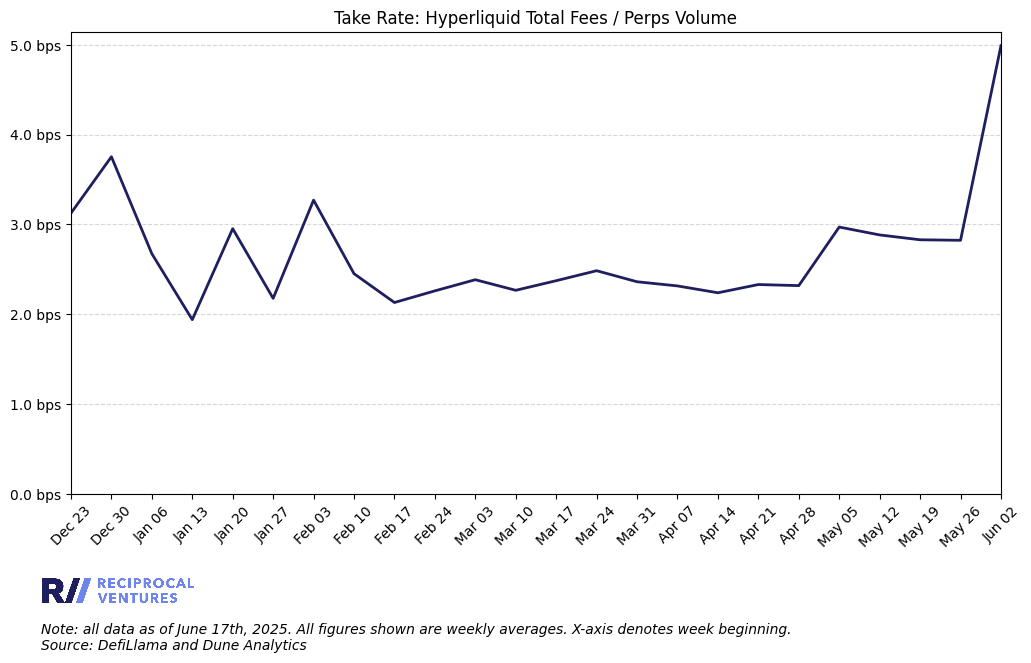

                                 volume        fees                      date  \
2025-05-05 00:00:00+00:00  4.750100e+10  14114342.0 2025-05-05 00:00:00+00:00   
2025-05-12 00:00:00+00:00  5.281727e+10  15231079.0 2025-05-12 00:00:00+00:00   
2025-05-19 00:00:00+00:00  7.867202e+10  22261980.0 2025-05-19 00:00:00+00:00   
2025-05-26 00:00:00+00:00  5.708573e+10  16121044.0 2025-05-26 00:00:00+00:00   
2025-06-02 00:00:00+00:00  2.501229e+10  12481394.0 2025-06-02 00:00:00+00:00   

                           take_rate_pct  
2025-05-05 00:00:00+00:00       0.029714  
2025-05-12 00:00:00+00:00       0.028837  
2025-05-19 00:00:00+00:00       0.028297  
2025-05-26 00:00:00+00:00       0.028240  
2025-06-02 00:00:00+00:00       0.049901  


In [51]:
asset = ['Hyperliquid Perps', 'hyperliquid', 'Hyperliquid'] # Dune Analytics label, DefiLlama label, title
volume_path = 'raw-data/dune-raw-data/dune_weekly-perps-dex-volumes.json'
fees_path = f"raw-data/defillama-raw-data/defillama_{asset[1]}-fees.json"

perp_dex_take_rate(asset = asset, volume_path = volume_path, fees_path = fees_path)

Skipped: TON Pump
Skipped: Perpie
          date  Telegram Bot Total Fees  Axiom Fees  Axiom / Telegram Bot  \
146 2025-06-11                 803572.0     1531192            190.548202   
147 2025-06-12                 634306.0     1417901            223.535801   
148 2025-06-13                 692643.0     1130756            163.252354   
149 2025-06-14                 487695.0      828166            169.812280   
150 2025-06-15                 516304.0      889660            172.313211   

     Axiom / Telegram Bot 7d  
146               157.399996  
147               172.611489  
148               173.651776  
149               173.699243  
150               174.745936  


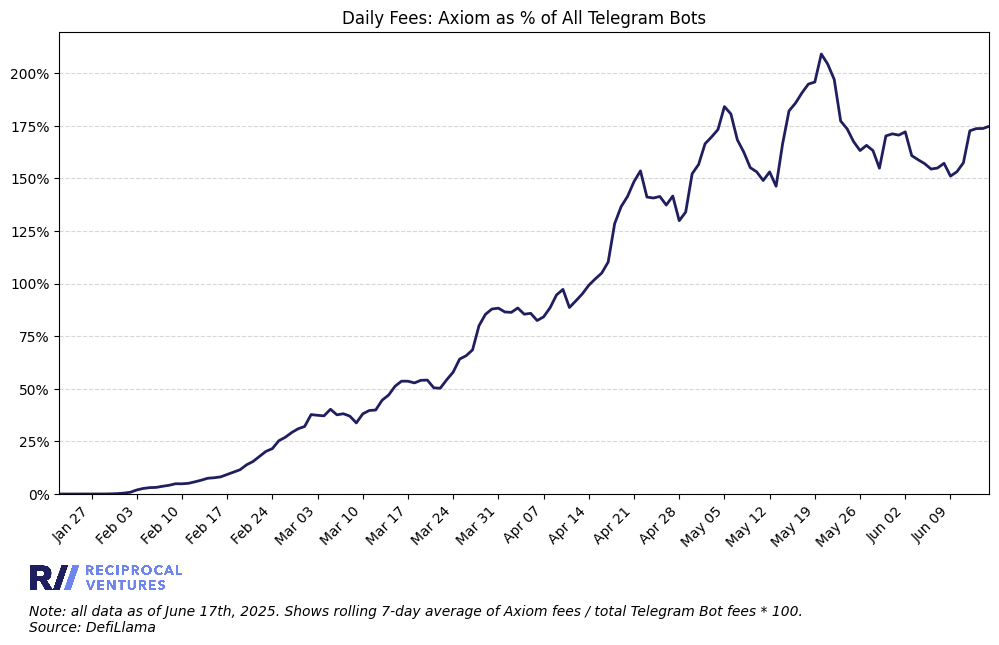

          date  Telegram Bot Total Fees  Axiom Fees  Axiom / Telegram Bot  \
141 2025-06-06                 769713.0     1200524            155.970342   
142 2025-06-07                 601478.0     1019385            169.480014   
143 2025-06-08                 559699.0      923427            164.986359   
144 2025-06-09                1044358.0     1451809            139.014495   
145 2025-06-10                 847499.0     1396214            164.745209   
146 2025-06-11                 803572.0     1531192            190.548202   
147 2025-06-12                 634306.0     1417901            223.535801   
148 2025-06-13                 692643.0     1130756            163.252354   
149 2025-06-14                 487695.0      828166            169.812280   
150 2025-06-15                 516304.0      889660            172.313211   

     Axiom / Telegram Bot 7d  
141               154.416361  
142               154.933601  
143               157.164220  
144               151.069740

In [54]:
start_date = '2025-01-01'
file_path = 'raw-data/defillama-raw-data/defillama_all-protocols.json'
category_name = 'Telegram Bot'
breakout_asset = 'Axiom'

def pull_category_defillama(file_path, category_name):
    with open (file_path, 'r') as f:
        data = json.load(f)

    # extract names of entries in the chosen category
    category_protocols = [
    entry['name']
    for entry in data
    if entry.get('category') == f'{category_name}'
    ]

    return category_protocols

# Pull category names
category_protocols = pull_category_defillama(file_path = file_path, category_name = category_name)

def fees_by_asset(start_date, category_protocols, category_name, breakout_asset):
    df_master = None
    # Load fee data
    for protocol in category_protocols:
        try:
            rev_path = f"raw-data/defillama-raw-data/dailyFees_data/{protocol}_Fees.json"
            with open(rev_path) as rev_f:
                rev_data = json.load(rev_f)
        
            rev_df = pd.DataFrame(rev_data["totalDataChart"], columns=["timestamp", f"{protocol}-Fees"])
            rev_df["date"] = pd.to_datetime(rev_df["timestamp"], unit="s")
            rev_df = rev_df[['date',f'{protocol}-Fees']]
        except:
            print(f'Skipped: {protocol}')
            continue

    # Merge asset dataframe into the master dataframe
        df_master = rev_df if df_master is None else df_master.merge(rev_df, on="date", how="outer")
        df_master = df_master.sort_values("date").reset_index(drop=True)

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    df_master = df_master.iloc[:-1]

    # Sum every column except 'date' into a new column
    cols_to_sum = [col for col in df_master.columns if col != 'date']
    df_master[f'{category_name} Total Fees'] = df_master[cols_to_sum].sum(axis=1)

    # Load breakout_asset fee data
    rev_path = f"raw-data/defillama-raw-data/dailyFees_data/{breakout_asset}_Fees.json"
    with open (rev_path) as rev_f:
        rev_data = json.load(rev_f)

    rev_df = pd.DataFrame(rev_data['totalDataChart'], columns = ['timestamp', f'{breakout_asset} Fees'])
    rev_df['date'] = pd.to_datetime(rev_df['timestamp'], unit='s')
    rev_df = rev_df[['date',f'{breakout_asset} Fees']]

    # Merge breakout asset into master dataframe
    df_master = df_master.merge(rev_df, on='date', how='inner')
    df_master = df_master.sort_values('date').reset_index(drop=True)
    df_master = df_master[['date',f'{category_name} Total Fees', f'{breakout_asset} Fees']]

    # Calculate multiple and calculate 7-day average
    df_master[f'{breakout_asset} / {category_name}'] = df_master[f'{breakout_asset} Fees'] / df_master[f'{category_name} Total Fees'] * 100 # convert to %
    df_master[f'{breakout_asset} / {category_name} 7d'] = df_master[f'{breakout_asset} / {category_name}'].rolling(window=7).mean()
    print(df_master.tail(5))
    
    # Begin charting
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot data
    ax.plot(df_master["date"], df_master[f'{breakout_asset} / {category_name} 7d'], color="#1f1f60", linewidth=2)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}%'))
    
    # X-axis formatting: show ticks weekly, on Mondays
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.margins(x=0)
    ax.set_ylim(bottom=0)
    
    # Clean up formatting
    ax.set_title(f'Daily Fees: {breakout_asset} as % of All {category_name}s')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.05, -0.18))
    plt.figtext(0.1, -0.12, f"Note: all data as of {date}. Shows rolling 7-day average of {breakout_asset} fees / total {category_name} fees * 100. \nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/fees_asset_vs_category.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print sample of the dataset with 7D average
    print(df_master.tail(10))

fees_by_asset(start_date, category_protocols, category_name, breakout_asset)

In [57]:
# Function for plotting gross margin for a given asset
def gross_margin_asset(start_date, assets, category_title):
    master_df = None
    
    # Load fees and revenue data
    for asset_slug, asset_name in assets.items():
        metrics = ['Fees', 'Revenue']
        interim_df = None
        for metric in metrics:
            asset_path = f"raw-data/defillama-raw-data/daily{metric}_data/{asset_slug}_{metric}.json"
            with open(asset_path) as asset_f:
                asset_data = json.load(asset_f)

            # Clean up asset dataframe
            asset_df = pd.DataFrame(asset_data["totalDataChart"], columns=["timestamp", f"{asset_slug}-{metric}"])
            asset_df["date"] = pd.to_datetime(asset_df["timestamp"], unit="s")
            asset_df = asset_df[["date", f"{asset_slug}-{metric}"]]
        
            # Merge metric-level asset dataframes for a given asset into the interim dataframe
            interim_df = asset_df if interim_df is None else interim_df.merge(asset_df, on="date", how="inner")
            interim_df = interim_df.sort_values("date").reset_index(drop=True)

        # Caculate gross margin for a given asset
        interim_df[f'{asset_slug}-gross-margin'] = interim_df[f'{asset_slug}-Revenue'] / interim_df[f'{asset_slug}-Fees']
        interim_df[f'{asset_slug}-gross-margin-7d'] = interim_df[f'{asset_slug}-gross-margin'].rolling(window=7).mean()

        # Merge interim dataframe into the master dataframe
        master_df = interim_df if master_df is None else master_df.merge(interim_df, on="date", how="outer")
        master_df = master_df.sort_values("date").reset_index(drop=True)

    # Cut off df_master to only be after start date
    master_df = master_df[master_df['date'] >= start_date]
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(10, 6))

    # Create color palette
    color_list = ['#1f1f60',
                '#313EA5',
                'grey',
                'black',
                '#333333',
                '#5F5F5F',
                '#8A8A8A',
                '#B6B6B6'
               ]

    color_palette = {}
    color_counter = 0
    
    for asset_slug, asset_name in assets.items():
        if asset_slug == 'hyperliquid':
            color_palette[f'{asset_name}'] = '#09b882'
        else:
            color_palette[f'{asset_name}'] = color_list[color_counter]
            color_counter = color_counter + 1
            
    # Prepare the values and colors in the right order
    dates   = master_df['date']
    series_list = [master_df[f'{asset_slug}-gross-margin-7d'] for asset_slug, asset_name in assets.items()]
    labels_list  = [asset_name for asset_slug, asset_name in assets.items()]
    colors_list = [color_palette[f'{asset_name}'] for asset_slug, asset_name in assets.items()]
    
    # Plotting the line chart with custom colors
    for i, (asset_slug, asset_name) in enumerate(assets.items()):
        ax.plot(
            dates, 
            series_list[i], 
            label = labels_list[i], 
            color = colors_list[i],
            linewidth=2
        )
    
    # Setting labels and title
    ax.set_title(f'{category_title}: Gross Margin')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x*100:,.0f}%'))
    ax.set_ylim(bottom=0)

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.08, -0.22))
    
    # Add sources and note
    text_box = ax.text(0, -0.47, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nGross margin calculated as fees / revenue, which is the % of fees the protocol keeps.\nFees data does not account for offchain rebates or incentives.\nSource: DefiLlama",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Center the legend below the chart
    plt.legend(title=f'Select {category_title}', bbox_to_anchor=(0.85, -0.17), loc='upper center', ncol=2)
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{category_title} gross margins.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

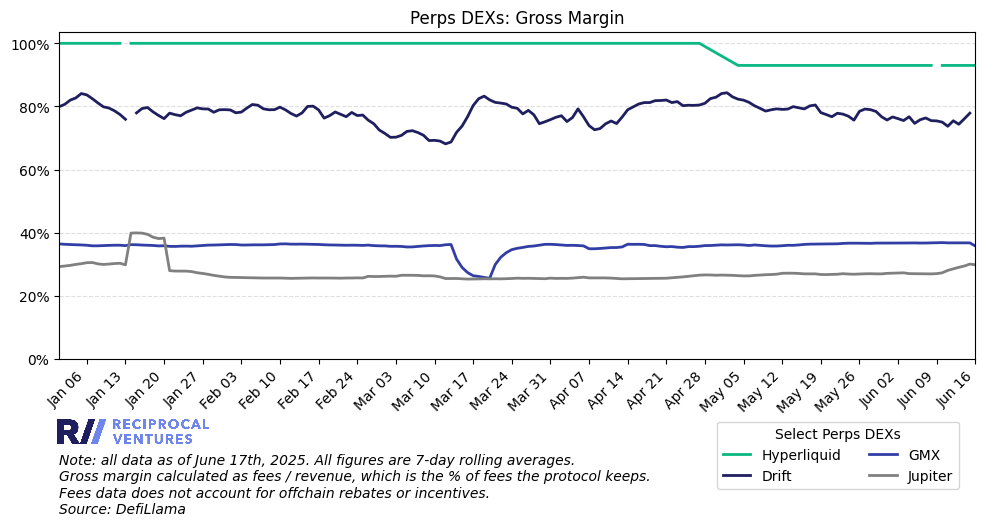

In [58]:
# call the function
perps_dexs = {'hyperliquid': 'Hyperliquid',
              'drift': 'Drift',
              'gmx': 'GMX',
              'jupiter': 'Jupiter'
         }
start_date = '2025-01-01'
assets = perps_dexs
category_title = 'Perps DEXs'

perps_gross_margins = gross_margin_asset(
    start_date     = start_date,
    assets         = perps_dexs,
    category_title = category_title
)